In [4]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
#
from Calculations_Functions import proportions_from_filename, metrics_table
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [5]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added.zarr'
filename2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/RESTART_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added_restart_365_days_no_release_1_year.zarr'

In [6]:
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
#
data = xr.open_dataset(filename1, engine = 'zarr', drop_variables=[v for v in xr.open_dataset(filename1, engine = 'zarr').variables if v not in vars_to_keep])
data2 = xr.open_dataset(filename2, engine = 'zarr', drop_variables=[v for v in xr.open_dataset(filename2, engine = 'zarr').variables if v not in vars_to_keep])

In [7]:
data_combined = xr.concat([data, data2], dim='obs' )

In [8]:
idx_JFM = int((90 * 86400) / 900)
idx_AMJ = int((181 * 86400) / 900)
idx_JAS = int((273 * 86400) / 900)
idx_OND = int((365 * 86400) / 900)
# 12 months
data_winter = data_combined.isel(trajectory=slice(0, idx_JFM), obs = slice(0, 365*4))
data_winter_W = data_winter.where((data_winter.status > 0) & (data_winter.status < 4))
data_winter_W_S = data_winter.where((data_winter.status > 0))
data_spring = data_combined.isel(trajectory=slice(idx_JFM, idx_AMJ), obs = slice(90*4, 365*4 + 90*4))
data_spring_W = data_spring.where((data_spring.status > 0) & (data_spring.status < 4))
data_spring_W_S = data_spring.where((data_spring.status > 0))
data_summer = data_combined.isel(trajectory=slice(idx_AMJ, idx_JAS), obs = slice(181*4, 365*4 + 181*4))
data_summer_W = data_summer.where((data_summer.status > 0) & (data_summer.status < 4))
data_summer_W_S = data_summer.where((data_summer.status > 0))
data_fall = data_combined.isel(trajectory=slice(idx_JAS, idx_OND), obs = slice(273*4, 365*4 + 273*4))
data_fall_W = data_fall.where((data_fall.status > 0) & (data_fall.status < 4))
data_fall_W_S = data_fall.where((data_fall.status > 0))

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Re-define the N-S Displacement Helper
def get_ns_displacement(lat_source, lat_array):
    R = 6371.0
    delta_lat_radians = np.radians(lat_array - lat_source)
    return R * delta_lat_radians

# 2. Define a function to process a specific season dataset
def analyze_season_ns(dataset, lat_source):
    """
    Returns (means, stds) arrays for North-South displacement over time.
    """
    # Auto-detect number of time steps (obs) in this slice
    # Assuming the dimensions are (trajectory, obs) based on your slicing
    num_timesteps = dataset.sizes['obs'] 
    
    means = []
    stds = []
    
    # Extract the full lat array to numpy once to speed up access (optional but recommended)
    all_lats = dataset['lat'].values
    
    for t in range(num_timesteps):
        # Get all particles for this specific time step
        current_lats = all_lats[:, t]
        
        # Calculate N/S distance in km
        ns_dists = get_ns_displacement(lat_source, current_lats)
        
        # Store stats
        means.append(np.nanmean(ns_dists))
        stds.append(np.nanstd(ns_dists))
        
    return np.array(means), np.array(stds)

In [10]:
# Source Latitude (from your previous snippet)
lat_source = 49.195045

# Process each season
mean_win_W, std_win_W = analyze_season_ns(data_winter_W, lat_source)
mean_spr_W, std_spr_W = analyze_season_ns(data_spring_W, lat_source)
mean_sum_W, std_sum_W = analyze_season_ns(data_summer_W, lat_source)
mean_fal_W, std_fal_W = analyze_season_ns(data_fall_W, lat_source)

# Organize them into a dictionary for easier plotting loop
seasons_W = {
    'Winter': (mean_win_W, std_win_W, 'k'), # Blue
    'Spring': (mean_spr_W, std_spr_W, 'r'), # Green
    'Summer': (mean_sum_W, std_sum_W, 'b'), # Red
    'Fall':   (mean_fal_W, std_fal_W, 'g')  # Orange
}
#
# Process each season
mean_win_W_S, std_win_W_S = analyze_season_ns(data_winter_W_S, lat_source)
mean_spr_W_S, std_spr_W_S = analyze_season_ns(data_spring_W_S, lat_source)
mean_sum_W_S, std_sum_W_S = analyze_season_ns(data_summer_W_S, lat_source)
mean_fal_W_S, std_fal_W_S = analyze_season_ns(data_fall_W_S, lat_source)

# Organize them into a dictionary for easier plotting loop
seasons_W_S = {
    'Winter': (mean_win_W_S, std_win_W_S, 'k'), # Blue
    'Spring': (mean_spr_W_S, std_spr_W_S, 'r'), # Green
    'Summer': (mean_sum_W_S, std_sum_W_S, 'b'), # Red
    'Fall':   (mean_fal_W_S, std_fal_W_S, 'g')  # Orange
}

/tmp/ipykernel_3316609/1239591362.py:33: RuntimeWarning: Mean of empty slice
  means.append(np.nanmean(ns_dists))
/home/vvalenzuela/conda_envs/Parcels/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


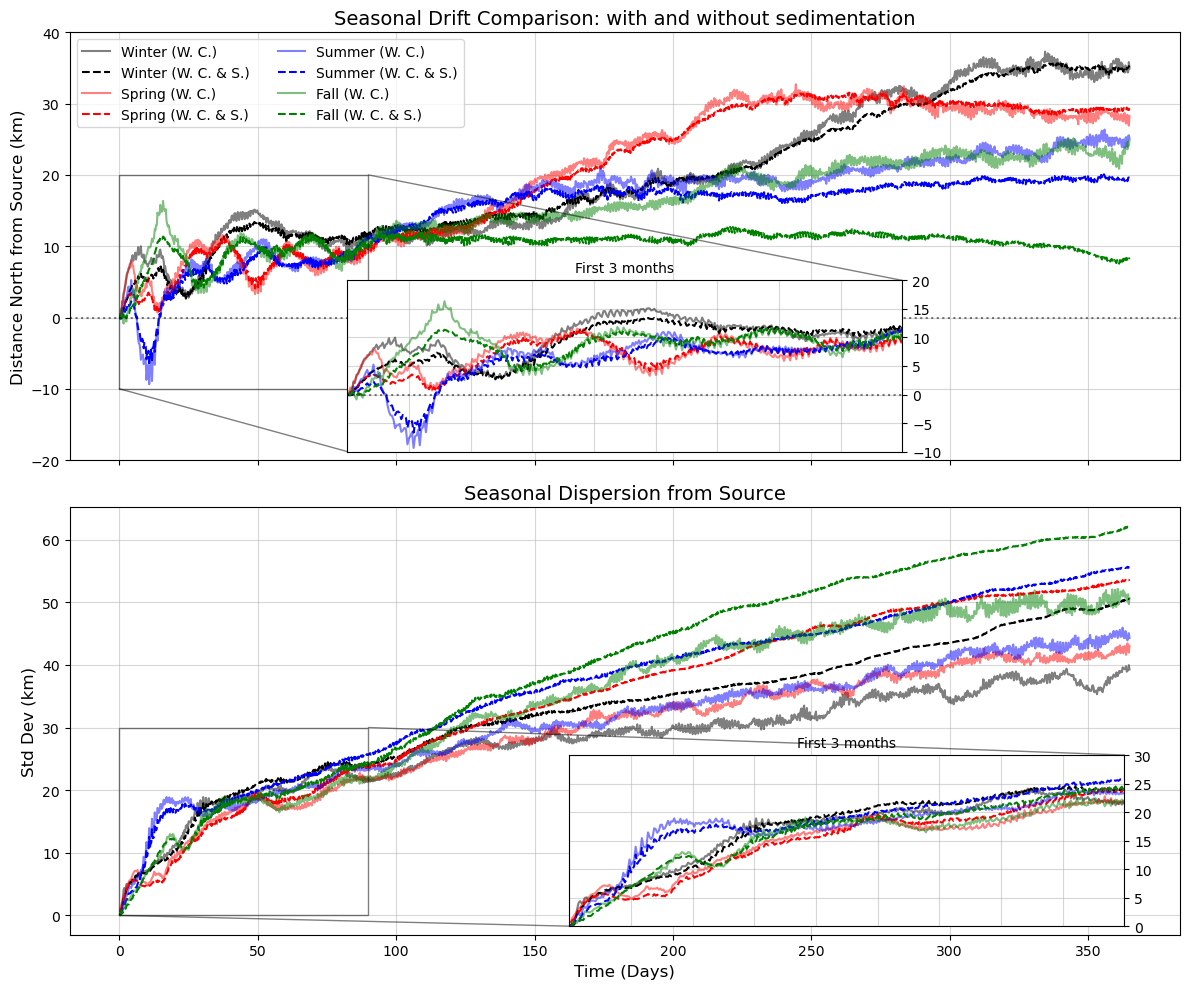

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- 1. Define the Inset Axis BEFORE the loop ---
# Placement: [x, y, width, height] in normalized (0-1) axes coordinates.
# 0.05, 0.55 places it in the Top Left (to avoid covering the data at the start)
# If you prefer Bottom Left (as in your snippet), change to [0.05, 0.05, 0.4, 0.4]
axins = ax1.inset_axes([0.25, 0.02, 0.5, 0.4]) 
axis = ax2.inset_axes([0.45, 0.02, 0.5, 0.4]) 


# --- 2. The Main Loop ---
for name in seasons_W.keys():
    # Unpack Water Column Data (Solid Line)
    mean_w, std_w, color = seasons_W[name]
    t_w = np.linspace(0,365,len(mean_w))
    
    # Unpack Sedimented Data (Dashed Line)
    mean_ws, std_ws, _ = seasons_W_S[name]
    t_ws = np.linspace(0,365,len(mean_ws))
    
    # --- Plot on Main Axis 1 (Drift) ---
    ax1.plot(t_w, mean_w, color=color, linestyle='-', linewidth=1.5, alpha = .5, label=f'{name} (W. C.)')
    ax1.plot(t_ws, mean_ws, color=color, linestyle='--', linewidth=1.5, label=f'{name} (W. C. & S.)')
    
    # --- Plot on Main Axis 2 (Dispersion) ---
    ax2.plot(t_w, std_w, color=color, linestyle='-', alpha = .5, linewidth=1.5)
    ax2.plot(t_ws, std_ws, color=color, linestyle='--', linewidth=1.5)

    # --- Plot on Inset Axis (The Zoom) ---
    # We use the same colors/styles so the user knows which line is which
    axins.plot(t_w, mean_w, color=color, linestyle='-', alpha = .5, linewidth=1.5)
    axins.plot(t_ws, mean_ws, color=color, linestyle='--', linewidth=1.5)
    #
    axis.plot(t_w, std_w, color=color, linestyle='-', alpha = .5, linewidth=1.5)
    axis.plot(t_ws, std_ws, color=color, linestyle='--', linewidth=1.5)

# --- 3. Formatting Main Plots ---
ax1.set_title('Seasonal Drift Comparison: with and without sedimentation', fontsize=14)
ax1.set_ylabel('Distance North from Source (km)', fontsize=12)
ax1.axhline(0, color='black', linestyle=':', alpha=0.5)
axins.axhline(0, color='black', linestyle=':', alpha=0.5)
ax1.grid(True, alpha=0.5)
ax1.legend(loc='upper left', ncol=2, fontsize=10) # Moved legend to avoid inset if top-left
ax1.set_ylim([-20, 40])

ax2.set_title('Seasonal Dispersion from Source', fontsize=14)
ax2.set_ylabel('Std Dev (km)', fontsize=12)
ax2.set_xlabel('Time (Days)', fontsize=12)
ax2.grid(True, alpha=0.5)

# --- 4. Formatting the Inset (The "Indep Map") ---
# Set the zoom limits you requested
x1, x2 = 0, 90  # First 360 points
y1, y2 = -10, 20 # Range of interest
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axis.set_xlim(x1, x2)
axis.set_ylim(0, 30)

# Styling
axins.set_title('First 3 months', fontsize=10); axis.set_title('First 3 months', fontsize=10)
axins.grid(True, linestyle='-', alpha=0.5); axis.grid(True, linestyle='-', alpha=0.5)
# Note: Keeping ticks OFF as you requested, but adding grid helps read it
axins.tick_params(axis='both', which='both', 
                  bottom=False, top=False, left=False, right=True, 
                  labelbottom=False, labelleft=False, labelright=True)
axis.tick_params(axis='both', which='both', 
                  bottom=False, top=False, left=False, right=True, 
                  labelbottom=False, labelleft=False, labelright=True)
# Draw the connector lines (The box showing where the zoom comes from)
ax1.indicate_inset_zoom(axins, edgecolor="k")
ax2.indicate_inset_zoom(axis, edgecolor="k")

plt.tight_layout()
plt.show()

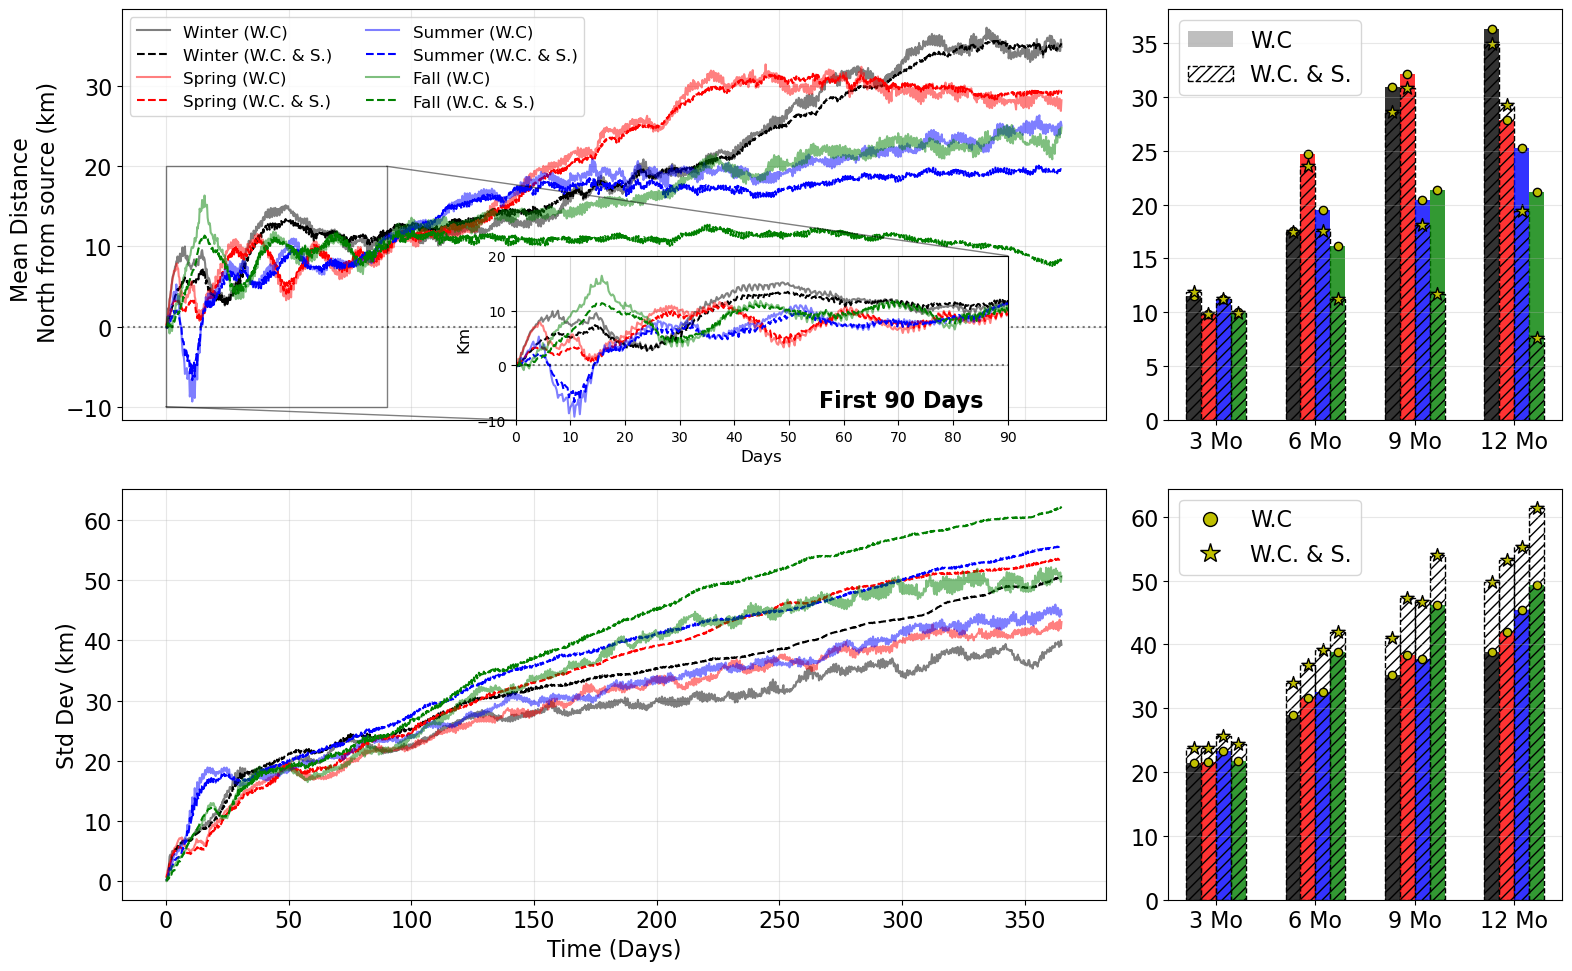

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 16})

# --- Setup Figure with 2 Columns ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [2.5, 1]})
(ax1_line, ax1_bar), (ax2_line, ax2_bar) = axes

# --- Configuration for Snapshots ---
snapshot_indices = [360, 720, 1080, 1440] 
snapshot_labels = ['3 Mo', '6 Mo', '9 Mo', '12 Mo']
bar_width = 0.15
season_offsets = np.linspace(-1.5 * bar_width, 1.5 * bar_width, 4)

# --- Main Loop Over Seasons ---
for i, name in enumerate(seasons_W.keys()):
    # 1. Unpack Data
    mean_w, std_w, color = seasons_W[name]
    mean_ws, std_ws, _ = seasons_W_S[name]
    
    # --- NEW: Create Time in Days (0 to 365) ---
    # This maps the array length to physical days
    t_days = np.linspace(0, 365, len(mean_w))
    
    # -------------------------------------------------------
    # LEFT COLUMN: Time Series (Now plotting vs t_days)
    # -------------------------------------------------------
    # Drift
    ax1_line.plot(t_days, mean_w, color=color, linestyle='-', linewidth=1.5, alpha=0.5, label=f'{name} (W.C)')
    ax1_line.plot(t_days, mean_ws, color=color, linestyle='--', linewidth=1.5, label=f'{name} (W.C. & S.)')
    
    # Dispersion
    ax2_line.plot(t_days, std_w, color=color, linestyle='-', alpha=0.5, linewidth=1.5)
    ax2_line.plot(t_days, std_ws, color=color, linestyle='--', linewidth=1.5)
    
    # -------------------------------------------------------
    # RIGHT COLUMN: Snapshots (Bar Plots)
    # -------------------------------------------------------
    indices = [min(idx, len(mean_w)-1) for idx in snapshot_indices]
    
    # Values
    val_drift_w = [mean_w[idx] for idx in indices]
    val_drift_ws = [mean_ws[idx] for idx in indices]
    val_disp_w = [std_w[idx] for idx in indices]
    val_disp_ws = [std_ws[idx] for idx in indices]
    
    x_pos = np.arange(len(indices)) + season_offsets[i]
    
    # --- Plot Drift Bars ---
    ax1_bar.bar(x_pos, val_drift_w, width=bar_width, color=color, alpha=0.8)
    ax1_bar.bar(x_pos, val_drift_ws, width=bar_width, color='none', edgecolor='black', 
                hatch='///', linestyle='--', linewidth=1, label=name if i==0 else "")
    ax1_bar.scatter(x_pos, val_drift_w, c='y', edgecolor='k')
    ax1_bar.scatter(x_pos, val_drift_ws, c='y', edgecolor='k', marker='*', s=100)

    # --- Plot Dispersion Bars ---
    ax2_bar.bar(x_pos, val_disp_w, width=bar_width, color=color, alpha=0.8)
    ax2_bar.bar(x_pos, val_disp_ws, width=bar_width, color='none', edgecolor='black', 
                hatch='///', linestyle='--', linewidth=1)
    ax2_bar.scatter(x_pos, val_disp_w, c='y', edgecolor='k')
    ax2_bar.scatter(x_pos, val_disp_ws, c='y', edgecolor='k', marker='*', s=100)

# -------------------------------------------------------
# FORMATTING & INSETS
# -------------------------------------------------------

# --- Top Left: Drift Time Series ---
ax1_line.set_ylabel('Mean Distance \n North from source (km)')
ax1_line.axhline(0, color='black', linestyle=':', alpha=0.5)
ax1_line.grid(True, alpha=0.3)
ax1_line.legend(loc='upper left', ncol=2, fontsize=12)
ax1_line.tick_params(bottom=False, labelbottom=False)

# --- Top Right: Drift Snapshots ---
ax1_bar.set_xticks(np.arange(len(snapshot_labels)))
ax1_bar.set_xticklabels(snapshot_labels)
ax1_bar.grid(True, axis='y', alpha=0.3)
legend_elements_1 = [Patch(facecolor='gray', alpha=0.5, label='W.C'),
                     Patch(facecolor='none', edgecolor='black', hatch='///', linestyle='--', label='W.C. & S.')]
ax1_bar.legend(handles=legend_elements_1, loc='upper left')

# --- Bottom Left: Dispersion Time Series ---
ax2_line.set_ylabel('Std Dev (km)')
ax2_line.set_xlabel('Time (Days)')  # UPDATED LABEL
ax2_line.grid(True, alpha=0.3)

# --- Bottom Right: Dispersion Snapshots ---
ax2_bar.set_xticks(np.arange(len(snapshot_labels)))
ax2_bar.set_xticklabels(snapshot_labels)
ax2_bar.grid(True, axis='y', alpha=0.3)
legend_elements_2 = [
    Line2D([0], [0], marker='o', color='w', label='W.C',
           markerfacecolor='y', markeredgecolor='k', markersize=10),
    Line2D([0], [0], marker='*', color='w', label='W.C. & S.',
           markerfacecolor='y', markeredgecolor='k', markersize=15)
]
ax2_bar.legend(handles=legend_elements_2, loc='upper left')

# --- Add the Zoom Inset ---
axins = ax1_line.inset_axes([0.4, 0.0, 0.5, 0.4]) 

# UPDATED: Zoom into 0-90 Days (First 3 months)
x1, x2, y1, y2 = 0, 90, -10, 20  
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(True, alpha=0.5)
axins.set_ylabel('Km', fontsize=12); axins.set_xlabel('Days', fontsize=12)
axins.tick_params(axis='x', labelsize=10); axins.tick_params(axis='y', labelsize=10)

# Re-plot data inside inset (using Days array)
for name in seasons_W.keys():
    c = seasons_W[name][2]
    # Create the Day array for this specific dataset
    t_days_ins = np.linspace(0, 365, len(seasons_W[name][0]))
    
    axins.plot(t_days_ins, seasons_W[name][0], color=c, linestyle='-', alpha=0.5, linewidth=1.5)
    axins.plot(t_days_ins, seasons_W_S[name][0], color=c, linestyle='--', linewidth=1.5)

axins.axhline(0, color='black', linestyle=':', alpha=0.5)        
ax1_line.indicate_inset_zoom(axins, edgecolor="k")
axins.text(0.95, 0.05, 'First 90 Days', 
           transform=axins.transAxes, 
           ha='right', va='bottom', 
           fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# Distance along Thalweg (S, n) method

In [13]:
thalweg = np.loadtxt('my_thalweg.txt', delimiter=' ', dtype=int)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [14]:
thalweg.shape[0]

785

In [15]:
t = 100
print(thalweg[t,0],thalweg[t,1])

320 102


In [16]:
lats = []
lons = []
for n in range(0, thalweg.shape[0]):
    lons.append(mask['nav_lon'][thalweg[n,0], thalweg[n,1]].values)
    lats.append(mask['nav_lat'][thalweg[n,0], thalweg[n,1]].values)


/tmp/ipykernel_3316609/419683407.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(mask['nav_lon'], mask['nav_lat'], mask['tmask'][0][0], cmap=cmap)


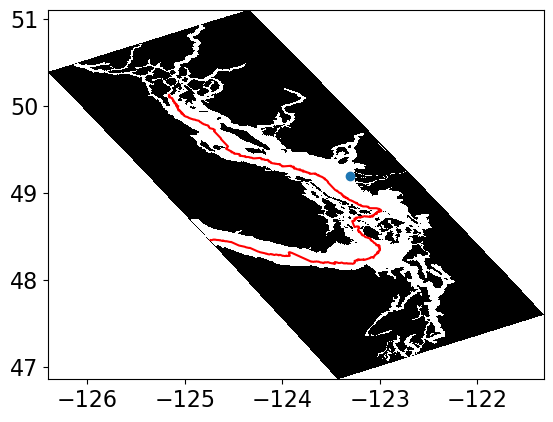

In [17]:
lat_source = 49.195045
lon_source = -123.301956
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
plt.pcolormesh(mask['nav_lon'], mask['nav_lat'], mask['tmask'][0][0], cmap=cmap)
plt.plot(lons, lats, 'r'); plt.scatter(lon_source, lat_source)
#plt.plot(thalweg[:,1], thalweg[:,0], 'r')

In [18]:
from scipy.spatial import cKDTree

def calculate_dispersion_metrics(p_lats, p_lons, thalweg_lats, thalweg_lons):
    """
    Calculates Along-Channel (s) and Cross-Channel (n) distances 
    directly from Latitude/Longitude coordinates.
    
    Handles NaNs/Infs in input arrays by returning NaN for those specific particles.
    """
    
    # --- STEP 1: "Flat Earth" Projection ---
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(49.0)) 
    
    # Project Thalweg to KM
    t_y_km = thalweg_lats * DEG_TO_KM
    t_x_km = thalweg_lons * DEG_TO_KM * lat_scale
    
    # Project Particles to KM
    # (NaNs will propagate here, which is fine for now)
    p_y_km = p_lats * DEG_TO_KM
    p_x_km = p_lons * DEG_TO_KM * lat_scale
    
    # --- STEP 2: Parameterize the Thalweg ---
    dy = np.diff(t_y_km)
    dx = np.diff(t_x_km)
    segment_lengths = np.sqrt(dy**2 + dx**2)
    thalweg_s_coords = np.concatenate(([0], np.cumsum(segment_lengths)))
    
    # Create the tree (Thalweg is assumed to be clean)
    thalweg_points = np.column_stack((t_y_km, t_x_km))
    tree = cKDTree(thalweg_points)
    
    # --- STEP 3: Handle NaNs and Query ---
    particle_points = np.column_stack((p_y_km, p_x_km))
    
    # Create a mask: True if BOTH Lat and Lon are finite numbers
    valid_mask = np.isfinite(particle_points).all(axis=1)
    
    # Prepare output arrays filled with NaNs
    # This ensures the output shape matches the input shape exactly
    s_dist = np.full(p_lats.shape, np.nan)
    n_dist = np.full(p_lats.shape, np.nan)
    
    # If there are no valid particles (e.g., before simulation start), return NaNs
    if not np.any(valid_mask):
        return s_dist, n_dist
        
    # Query the tree ONLY using valid particles
    # subset_points is a smaller array containing only "real" particles
    subset_points = particle_points[valid_mask]
    
    valid_n_dist, valid_idx = tree.query(subset_points)
    
    # --- STEP 4: Reconstruct the full array ---
    # We put the calculated values back into their original slots
    s_dist[valid_mask] = thalweg_s_coords[valid_idx]
    n_dist[valid_mask] = valid_n_dist
    
    return s_dist, n_dist

In [19]:
from scipy.spatial import cKDTree

def get_full_dispersion_stats(ds, thalweg_lats, thalweg_lons):
    """
    Calculates Mean Position, Lateral Width, and Longitudinal Length 
    of the particle cloud over time.
    """
    
    # --- A. Setup Projection & Tree (Do this ONCE) ---
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(49.0)) 
    
    # Project Thalweg
    t_y_km = thalweg_lats * DEG_TO_KM
    t_x_km = thalweg_lons * DEG_TO_KM * lat_scale
    
    # Calculate S-coordinates (distance along thalweg)
    dy = np.diff(t_y_km)
    dx = np.diff(t_x_km)
    segment_lengths = np.sqrt(dy**2 + dx**2)
    thalweg_s_coords = np.concatenate(([0], np.cumsum(segment_lengths)))
    
    # Build Tree
    thalweg_points = np.column_stack((t_y_km, t_x_km))
    tree = cKDTree(thalweg_points)
    
    # --- B. Prepare Storage ---
    n_timesteps = len(ds['obs'])
    
    ts_mean_dist = np.zeros(n_timesteps) # Center of mass (km)
    ts_lat_disp  = np.zeros(n_timesteps) # Cross-channel spread (sigma_n)
    ts_long_disp = np.zeros(n_timesteps) # Along-channel spread (sigma_s)
    
    print(f"Processing {n_timesteps} time steps...")

    # --- C. The Loop ---
    for t in range(n_timesteps):
        
        # 1. Get Particle Data
        p_lats = ds['lat'].isel(obs=t).values 
        p_lons = ds['lon'].isel(obs=t).values
        
        # 2. Project
        p_y_km = p_lats * DEG_TO_KM
        p_x_km = p_lons * DEG_TO_KM * lat_scale
        particle_points = np.column_stack((p_y_km, p_x_km))
        
        # 3. Mask NaNs
        valid_mask = np.isfinite(particle_points).all(axis=1)
        
        if not np.any(valid_mask):
            ts_mean_dist[t] = np.nan
            ts_lat_disp[t]  = np.nan
            ts_long_disp[t] = np.nan
            continue

        # 4. Query Tree
        subset_points = particle_points[valid_mask]
        n_dist_vals, idx = tree.query(subset_points)
        s_dist_vals = thalweg_s_coords[idx]
        
        # 5. Calculate Statistics
        # Mean Distance from Source
        ts_mean_dist[t] = np.mean(s_dist_vals)
        
        # Lateral Dispersion (Std Dev of Cross-Channel distance)
        ts_lat_disp[t] = np.std(n_dist_vals)
        
        # Longitudinal Dispersion (Std Dev of Along-Channel distance)
        ts_long_disp[t] = np.std(s_dist_vals)
        
    return ts_mean_dist, ts_lat_disp, ts_long_disp

In [20]:

from scipy.spatial import cKDTree

def calculate_signed_distance(p_lats, p_lons, thalweg_lats, thalweg_lons, 
                              source_lat=49.195045, source_lon=-123.301956):
    """
    Calculates distance along the thalweg relative to a specific source point.
    Returns:
        signed_dist: Distance in km. 
                     0 = At Source.
                     Positive = North of Source.
                     Negative = South of Source.
        cross_dist: Distance from the centerline (width).
    """
    
    # --- 1. Flat Earth Projection (Lat/Lon -> km) ---
    # Centered at the Source Latitude to minimize distortion
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(source_lat)) 
    
    def project_to_km(lats, lons):
        y = lats * DEG_TO_KM
        x = lons * DEG_TO_KM * lat_scale
        return y, x

    t_y, t_x = project_to_km(thalweg_lats, thalweg_lons)
    p_y, p_x = project_to_km(p_lats, p_lons)
    src_y, src_x = project_to_km(source_lat, source_lon)

    # --- 2. Build the "Ruler" (Thalweg S-coordinates) ---
    # Calculate distance between every point on the red line
    dy = np.diff(t_y)
    dx = np.diff(t_x)
    segment_lengths = np.sqrt(dy**2 + dx**2)
    # s_coords is the cumulative distance from the START of the array
    s_coords = np.concatenate(([0], np.cumsum(segment_lengths)))
    
    # --- 3. Find s_source (The Zero Point) ---
    thalweg_points = np.column_stack((t_y, t_x))
    tree = cKDTree(thalweg_points)
    
    # Find nearest point on thalweg to the Iona Source
    _, src_idx = tree.query([[src_y, src_x]])
    s_source = s_coords[src_idx[0]]
    
    # --- 4. Find s_particles ---
    particle_points = np.column_stack((p_y, p_x))
    
    # Handle NaNs (Particles not released yet)
    valid_mask = np.isfinite(particle_points).all(axis=1)
    
    output_s = np.full(p_lats.shape, np.nan)
    output_n = np.full(p_lats.shape, np.nan)
    
    if np.any(valid_mask):
        subset = particle_points[valid_mask]
        n_dist, idx = tree.query(subset)
        s_particle = s_coords[idx]
        
        # --- 5. Apply Sign Convention (North = Positive) ---
        # Determine if the Thalweg array was defined North->South or South->North
        # We check the latitude of the first vs last point
        thalweg_is_north_to_south = thalweg_lats[0] > thalweg_lats[-1]
        
        # Calculate raw difference relative to source
        delta_s = s_particle - s_source
        
        if thalweg_is_north_to_south:
            # If array starts North (0) and goes South (max), 
            # then increasing 's' means going South.
            # We want South to be Negative, so we invert the sign.
            signed_s = -delta_s
        else:
            # If array starts South (0) and goes North (max),
            # then increasing 's' means going North.
            # This matches your desire (North = Positive).
            signed_s = delta_s
            
        output_s[valid_mask] = signed_s
        output_n[valid_mask] = n_dist

    return output_s, output_n

In [21]:
from scipy.spatial import cKDTree

def get_dispersion_time_series(p_lats_2d, p_lons_2d, thalweg_lats, thalweg_lons, 
                               source_lat=49.195045, source_lon=-123.301956):
    """
    Calculates particle dispersion relative to the Thalweg and Source.
    
    CONVENTION:
    - Positive Distance (+): Transport Northward (Up-Estuary)
    - Negative Distance (-): Transport Southward (Towards Juan de Fuca/Ocean)
    
    Input: 2D arrays of particle coordinates (Particles x Time)
    Output: 1D Time-Series arrays (Mean S, Std S, Mean N, Std N)
    """
    
    # 1. Capture original shape
    n_particles, n_timesteps = p_lats_2d.shape
    
    # 2. Flatten inputs to 1D
    lats_flat = p_lats_2d.ravel()
    lons_flat = p_lons_2d.ravel()
    
    # --- PROJECTION LOGIC ---
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(source_lat)) 
    
    def project_to_km(lats, lons):
        y = lats * DEG_TO_KM
        x = lons * DEG_TO_KM * lat_scale
        return y, x

    t_y, t_x = project_to_km(thalweg_lats, thalweg_lons)
    p_y, p_x = project_to_km(lats_flat, lons_flat)
    src_y, src_x = project_to_km(source_lat, source_lon)

    # Build Ruler (S-coordinates)
    dy = np.diff(t_y)
    dx = np.diff(t_x)
    segment_lengths = np.sqrt(dy**2 + dx**2)
    s_coords = np.concatenate(([0], np.cumsum(segment_lengths)))
    
    # Find Source S (The Zero Point)
    tree = cKDTree(np.column_stack((t_y, t_x)))
    _, src_idx = tree.query([[src_y, src_x]])
    s_source = s_coords[src_idx[0]]
    
    # --- DIRECTION DETECTION (The Safety Check) ---
    # We check if the Thalweg array starts North and goes South, or vice versa.
    thalweg_starts_north = thalweg_lats[0] > thalweg_lats[-1]
    
    if thalweg_starts_north:
        print("✅ Thalweg orientation: North -> South. Inverting sign so South is Negative.")
    else:
        print("✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).")

    # --- CALCULATION ---
    # Create empty arrays to hold results
    s_flat = np.full(lats_flat.shape, np.nan)
    n_flat = np.full(lats_flat.shape, np.nan)
    
    # Mask NaNs
    particle_points = np.column_stack((p_y, p_x))
    valid_mask = np.isfinite(particle_points).all(axis=1)
    
    if np.any(valid_mask):
        subset = particle_points[valid_mask]
        n_dist, idx = tree.query(subset)
        s_particle = s_coords[idx]
        
        # Calculate raw distance from source (magnitude only)
        delta_s = s_particle - s_source
        
        # --- SIGN LOGIC (Guaranteed) ---
        if thalweg_starts_north:
            # Thalweg Array: [0=North, Max=South]
            # If particle is South of source, s_particle > s_source -> delta_s is Positive.
            # We want South to be Negative.
            signed_s = -delta_s 
        else:
            # Thalweg Array: [0=South, Max=North]
            # If particle is South of source, s_particle < s_source -> delta_s is Negative.
            # We want South to be Negative.
            signed_s = delta_s
            
        s_flat[valid_mask] = signed_s
        n_flat[valid_mask] = n_dist

    # --- RESHAPE & AGGREGATE ---
    s_matrix = s_flat.reshape(n_particles, n_timesteps)
    n_matrix = n_flat.reshape(n_particles, n_timesteps)
    
    ts_mean_s = np.nanmean(s_matrix, axis=0) 
    ts_std_s  = np.nanstd(s_matrix, axis=0) 
    ts_mean_n = np.nanmean(n_matrix, axis=0)
    ts_std_n  = np.nanstd(n_matrix, axis=0) 
    
    return ts_mean_s, ts_std_s, ts_mean_n, ts_std_n

In [22]:
# Example Usage
# 1. Load your thalweg (Just once)
thalweg_lats = np.array(lats) # Your predefined line
thalweg_lons = np.array(lons) 

# 2. Get particle data at a specific time step (e.g., t=24 hours)
data = data_winter_W.isel(obs=-1) 
current_lats = data['lat'].values
current_lons = data['lon'].values

# 3. Calculate metrics
along_channel, cross_channel = calculate_dispersion_metrics(
    current_lats, 
    current_lons, 
    thalweg_lats, 
    thalweg_lons
)

# 4. The Result
print(f"Average distance traveled: {np.nanmean(along_channel):.2f} km")
print(f"Cloud Width (Dispersion): {np.nanstd(cross_channel):.2f} km")

Average distance traveled: 406.76 km
Cloud Width (Dispersion): 14.11 km


In [23]:
mean_S, std_S, mean_N, std_N = get_dispersion_time_series(
    data_winter_W['lat'].values, 
    data_winter_W['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)

✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).


/tmp/ipykernel_3316609/1712376913.py:92: RuntimeWarning: Mean of empty slice
  ts_mean_s = np.nanmean(s_matrix, axis=0)
/home/vvalenzuela/conda_envs/Parcels/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3316609/1712376913.py:94: RuntimeWarning: Mean of empty slice
  ts_mean_n = np.nanmean(n_matrix, axis=0)


In [24]:
out_S, out_N = calculate_signed_distance(data_winter_W['lat'].values.ravel(), data_winter_W['lon'].values.ravel(),
                                          thalweg_lats=thalweg_lats, thalweg_lons=thalweg_lons)

In [25]:
mean_s, std_n, std_s = get_full_dispersion_stats(data_winter_W_S, thalweg_lats=thalweg_lats, thalweg_lons=thalweg_lons)

Processing 1460 time steps...


In [26]:
source_lat=49.195045; source_lon=-123.301956
jjii = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i
#################################################################################################    

In [27]:
from matplotlib.collections import LineCollection
def visualize_dispersion_analysis(mean_S, std_S, mean_N, std_N, 
                                  thalweg_lats, thalweg_lons,mask_land,
                                  source_lat=49.195045, source_lon=-123.301956):
    """
    Plots the statistical time-series next to a map of the domain.
    The Thalweg on the map is colored to match the +/- convention of the plots.
    """
    
    # Create layout: Map on Left, Time-Series stacked on Right
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.2])

    ax_map = fig.add_subplot(gs[:, 0])
    ax_long = fig.add_subplot(gs[0, 1])
    ax_lat = fig.add_subplot(gs[1, 1], sharex=ax_long)
    
    time_hours = np.linspace(0, 365, len(mean_S))

    # --- 1. MAP PLOT (Left Panel) ---
    # A. Background Land Mask
    colors_0 = [(0, 0, 0, 1),   # Black for land
                (0, 0, 0, 0)]   # Transparent for water
    cmap_land = ListedColormap(colors_0)
    ax_map.pcolormesh(mask_land, cmap=cmap_land, shading='auto', zorder=1)  
    # B. Calculate Thalweg Distance Gradient for Coloring
    # (We re-run a simplified projection here to color the line segments)
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(source_lat))
    t_y = thalweg_lats * DEG_TO_KM
    t_x = thalweg_lons * DEG_TO_KM * lat_scale
    
    # Cumulative distance
    dy = np.diff(t_y)
    dx = np.diff(t_x)
    s_vals = np.concatenate(([0], np.cumsum(np.sqrt(dy**2 + dx**2))))
    
    # Find source on thalweg
    tree = cKDTree(np.column_stack((t_y, t_x)))
    src_y = source_lat * DEG_TO_KM
    src_x = source_lon * DEG_TO_KM * lat_scale
    _, src_idx = tree.query([[src_y, src_x]])
    s_source = s_vals[src_idx[0]]
    
    # Adjust for +/- direction
    thalweg_dist = s_vals - s_source
    if thalweg_lats[0] > thalweg_lats[-1]: # If North to South
        thalweg_dist = -thalweg_dist
        
    # C. Plot Colored Thalweg Line (Multicolor Line Collection)
    points = np.array([thalweg[:,1], thalweg[:,0]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Use Red-Blue colormap: Red = Negative (South), Blue = Positive (North)
    norm = plt.Normalize(-150, 150) # Adjust limits based on your domain extent
    lc = LineCollection(segments, cmap=cm.curl, norm=norm, linewidth=4, zorder=2)
    lc.set_array(thalweg_dist)
    ax_map.add_collection(lc)
    
    # D. Add Source
    a, b = finder(source_lat,source_lon)
    ax_map.scatter(b, a, c='gold', s=200, marker='*', edgecolors='k', zorder=3, label='Iona')
    
    # E. Formatting
    ax_map.set_title("Model Domain", fontsize=14)
    ax_map.legend()
    ax_map.set_aspect('equal') # Important for maps
    
    # Add a horizontal colorbar for the map
    cbar = plt.colorbar(lc, ax=ax_map, orientation='horizontal', pad=0.05, aspect=30)
    cbar.set_label('Thalweg Distance (km): Red=South(-), Blue=North(+)')

    # --- 2. TIME SERIES PLOTS (Right Panel) ---
    # Longitudinal
    ax_long.plot(time_hours, mean_S, color='blue', lw=2, label='Mean Position (S)')
    ax_long.fill_between(time_hours, mean_S - std_S, mean_S + std_S, 
                     color='blue', alpha=0.2, label='Longitudinal Spread (±1 std)')
    ax_long.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax_long.set_ylabel('Along-Thalweg Distance (km)\n(- South / + North)', fontsize=12)
    ax_long.set_title('Longitudinal Transport', fontsize=14)
    ax_long.legend(loc='upper left')
    ax_long.grid(True, alpha=0.3)

    # Lateral
    ax_lat.plot(time_hours, mean_N, color='red', lw=2, label='Mean Offset (N)')
    ax_lat.fill_between(time_hours, mean_N - std_N, mean_N + std_N, 
                     color='red', alpha=0.2, label='Lateral Spread (±1 std)')
    ax_lat.set_ylabel('Cross-Channel Distance (km)', fontsize=12)
    ax_lat.set_xlabel('Time (Obs)', fontsize=12)
    ax_lat.set_title('Lateral Dispersion (Width)', fontsize=14)
    ax_lat.legend(loc='upper left')
    ax_lat.grid(True, alpha=0.3)
    ax_lat.set_ylim(-10, 40) # As requested

    plt.tight_layout()
    plt.show()

In [28]:
mean_S_winter_W, std_S_winter_W, mean_N_winter_W, std_N_winter_W = get_dispersion_time_series(
    data_winter_W['lat'].values, 
    data_winter_W['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)
#
mean_S_spring_W, std_S_spring_W, mean_N_spring_W, std_N_spring_W = get_dispersion_time_series(
    data_spring_W['lat'].values, 
    data_spring_W['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)
#
mean_S_summer_W, std_S_summer_W, mean_N_summer_W, std_N_summer_W = get_dispersion_time_series(
    data_summer_W['lat'].values, 
    data_summer_W['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)
#
mean_S_fall_W, std_S_fall_W, mean_N_fall_W, std_N_fall_W = get_dispersion_time_series(
    data_fall_W['lat'].values, 
    data_fall_W['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)

✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).


/tmp/ipykernel_3316609/1712376913.py:92: RuntimeWarning: Mean of empty slice
  ts_mean_s = np.nanmean(s_matrix, axis=0)
/tmp/ipykernel_3316609/1712376913.py:94: RuntimeWarning: Mean of empty slice
  ts_mean_n = np.nanmean(n_matrix, axis=0)


✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).
✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).
✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).


In [29]:
mean_S_winter_W_S, std_S_winter_W_S, mean_N_winter_W_S, std_N_winter_W_S = get_dispersion_time_series(
    data_winter_W_S['lat'].values, 
    data_winter_W_S['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)
#
mean_S_spring_W_S, std_S_spring_W_S, mean_N_spring_W_S, std_N_spring_W_S = get_dispersion_time_series(
    data_spring_W_S['lat'].values, 
    data_spring_W_S['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)
#
mean_S_summer_W_S, std_S_summer_W_S, mean_N_summer_W_S, std_N_summer_W_S = get_dispersion_time_series(
    data_summer_W_S['lat'].values, 
    data_summer_W_S['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)
#
mean_S_fall_W_S, std_S_fall_W_S, mean_N_fall_W_S, std_N_fall_W_S = get_dispersion_time_series(
    data_fall_W_S['lat'].values, 
    data_fall_W_S['lon'].values, 
    thalweg_lats, 
    thalweg_lons
)

✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).


/tmp/ipykernel_3316609/1712376913.py:92: RuntimeWarning: Mean of empty slice
  ts_mean_s = np.nanmean(s_matrix, axis=0)
/tmp/ipykernel_3316609/1712376913.py:94: RuntimeWarning: Mean of empty slice
  ts_mean_n = np.nanmean(n_matrix, axis=0)


✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).
✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).
✅ Thalweg orientation: South -> North. Keeping sign (South is naturally Negative).


In [30]:
seasonal_results_W = {
    'Winter': (mean_S_winter_W, std_S_winter_W, mean_N_winter_W, std_N_winter_W),
    'Spring': (mean_S_spring_W, std_S_spring_W, mean_N_spring_W, std_N_spring_W),
    'Summer': (mean_S_summer_W, std_S_summer_W, mean_N_summer_W, std_N_summer_W),
    'Fall':   (mean_S_fall_W,   std_S_fall_W,   mean_N_fall_W,   std_N_fall_W)
}
#
seasonal_results_W_S = {
    'Winter': (mean_S_winter_W_S, std_S_winter_W_S, mean_N_winter_W_S, std_N_winter_W_S),
    'Spring': (mean_S_spring_W_S, std_S_spring_W_S, mean_N_spring_W_S, std_N_spring_W_S),
    'Summer': (mean_S_summer_W_S, std_S_summer_W_S, mean_N_summer_W_S, std_N_summer_W_S),
    'Fall':   (mean_S_fall_W_S,   std_S_fall_W_S,   mean_N_fall_W_S,   std_N_fall_W_S)
}

In [31]:
def visualize_seasonal_comparison(seasonal_results, 
                                  thalweg_lats, thalweg_lons, 
                                  mask_land,
                                  thalweg_indices, 
                                  source_indices,  
                                  sediment_results=None,
                                  source_lat=49.195045, source_lon=-123.301956,
                                  seasons_order=['Winter', 'Spring', 'Summer', 'Fall']):
    from matplotlib.ticker import MaxNLocator
    # Create Figure
    fig = plt.figure(figsize=(23, 16))
    gs = fig.add_gridspec(4, 3, width_ratios=[1, 1, 0.8])
    
    # --- 1. PLOT THE SEASONS (Columns 0 and 1) ---
    for i, season in enumerate(seasons_order):
        if season not in seasonal_results:
            continue
            
        mean_S, std_S, mean_N, std_N = seasonal_results[season]
        
        # User requested 0 to 365 scaling
        time = np.linspace(0, 365, len(mean_S))
        
        # Longitudinal (Col 0)
        ax_s = fig.add_subplot(gs[i, 0])
        ax_s.plot(time, mean_S, color='blue', lw=2, linestyle='-', label='W.')
        ax_s.fill_between(time, mean_S - std_S, mean_S + std_S, color='blue', alpha=0.2)
        
        # Sediment (Dashed) if available
        if sediment_results and season in sediment_results:
            s_mean_sed, s_std_sed, _, _ = sediment_results[season]
            time_sed = np.linspace(0, 365, len(s_mean_sed)) # Use same scaling
            ax_s.plot(time_sed, s_mean_sed, color='navy', lw=2, linestyle='--', label='W. & S.')
            ax_s.fill_between(time_sed, s_mean_sed - s_std_sed, s_mean_sed + s_std_sed, color='navy', alpha=0.1)

        ax_s.axhline(0, color='k', linestyle='--', alpha=0.5)
        ax_s.grid(True, alpha=0.3)
        ax_s.set_ylabel(f"{season}\nDistance (km)", fontweight='bold', fontsize=20)
        ax_s.set_ylim(-180, 180) 
        ax_s.yaxis.set_major_locator(MaxNLocator(6))
        if i == 0: 
            ax_s.set_title("Longitudinal Transport (s)", fontsize=24)
            ax_s.legend(loc='upper left', fontsize='small')
        if i == 3: ax_s.set_xlabel("Time (Days)", fontsize=24)
        else: ax_s.set_xticklabels([])

        # Lateral (Col 1)
        ax_n = fig.add_subplot(gs[i, 1])
        ax_n.plot(time, mean_N, color='red', lw=2, linestyle='-', label='W.')
        ax_n.fill_between(time, mean_N - std_N, mean_N + std_N, color='red', alpha=0.2)
        
        # Sediment (Dashed) if available
        if sediment_results and season in sediment_results:
            _, _, n_mean_sed, n_std_sed = sediment_results[season]
            time_sed = np.linspace(0, 365, len(n_mean_sed))
            ax_n.plot(time_sed, n_mean_sed, color='darkred', lw=2, linestyle='--', label='W. & S.')
            ax_n.fill_between(time_sed, n_mean_sed - n_std_sed, n_mean_sed + n_std_sed, color='darkred', alpha=0.1)

        ax_n.axhline(0, color='k', linestyle='--', alpha=0.5)
        ax_n.grid(True, alpha=0.3)
        ax_n.set_ylim(-10, 40) 
        ax_n.yaxis.set_major_locator(MaxNLocator(6))
        if i == 0: 
            ax_n.set_title("Lateral Dispersion (n)", fontsize=24)
            ax_n.legend(loc='upper left', fontsize='small')
        if i == 3: ax_n.set_xlabel("Time (Days)", fontsize=24)
        else: ax_n.set_xticklabels([])
            
    # --- 2. PLOT THE MAP (Column 2, spanning All Rows) ---
    ax_map = fig.add_subplot(gs[:, 2])
    
    # A. Land Mask (Using Grid Indices)
    colors_0 = [(0, 0, 0, 1), (0, 0, 0, 0)]
    cmap_land = ListedColormap(colors_0)
    ax_map.pcolormesh(mask_land, cmap=cmap_land, shading='auto', zorder=1)
    
    # B. Calculate Thalweg Distance for Coloring
    # (Distance logic remains physical - Lat/Lon based)
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(source_lat))
    t_y = thalweg_lats * DEG_TO_KM
    t_x = thalweg_lons * DEG_TO_KM * lat_scale
    dy = np.diff(t_y)
    dx = np.diff(t_x)
    s_vals = np.concatenate(([0], np.cumsum(np.sqrt(dy**2 + dx**2))))
    
    # Find source distance
    tree = cKDTree(np.column_stack((t_y, t_x)))
    src_y = source_lat * DEG_TO_KM
    src_x = source_lon * DEG_TO_KM * lat_scale
    _, src_idx = tree.query([[src_y, src_x]])
    s_source = s_vals[src_idx[0]]
    
    # Adjust sign
    thalweg_dist = s_vals - s_source
    if thalweg_lats[0] > thalweg_lats[-1]:
        thalweg_dist = -thalweg_dist
        
    # C. Plot Thalweg (Using Grid Indices)
    # thalweg_indices must be shape (N, 2) where col 0 is y, col 1 is x
    points = np.array([thalweg_indices[:,1], thalweg_indices[:,0]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(-150, 150)
    lc = LineCollection(segments, cmap='Spectral', norm=norm, linewidth=4, zorder=2)
    lc.set_array(thalweg_dist)
    ax_map.add_collection(lc)
    
    # D. Source & Formatting (Using Grid Indices)
    # source_indices should be (y, x) -> plot (x, y)
    src_y_idx, src_x_idx = source_indices
    ax_map.scatter(src_x_idx, src_y_idx, c='gold', s=200, marker='*', edgecolors='k', zorder=3, label='Iona Outfall')
    
    ax_map.set_aspect(1.14)
    ax_map.legend(loc='lower right', fontsize = 24)
    ax_map.set_xticks([]); ax_map.set_yticks([])
    ax_map.set_title(r'Thalweg $D(s,n)$', fontsize = 24)
    # Vertical Colorbar
    cbar = plt.colorbar(lc, ax=ax_map, orientation='vertical', pad=0.05, fraction=0.08)
    cbar.set_label('Distance (km)', fontsize=24)
    
    plt.tight_layout()
    plt.show()

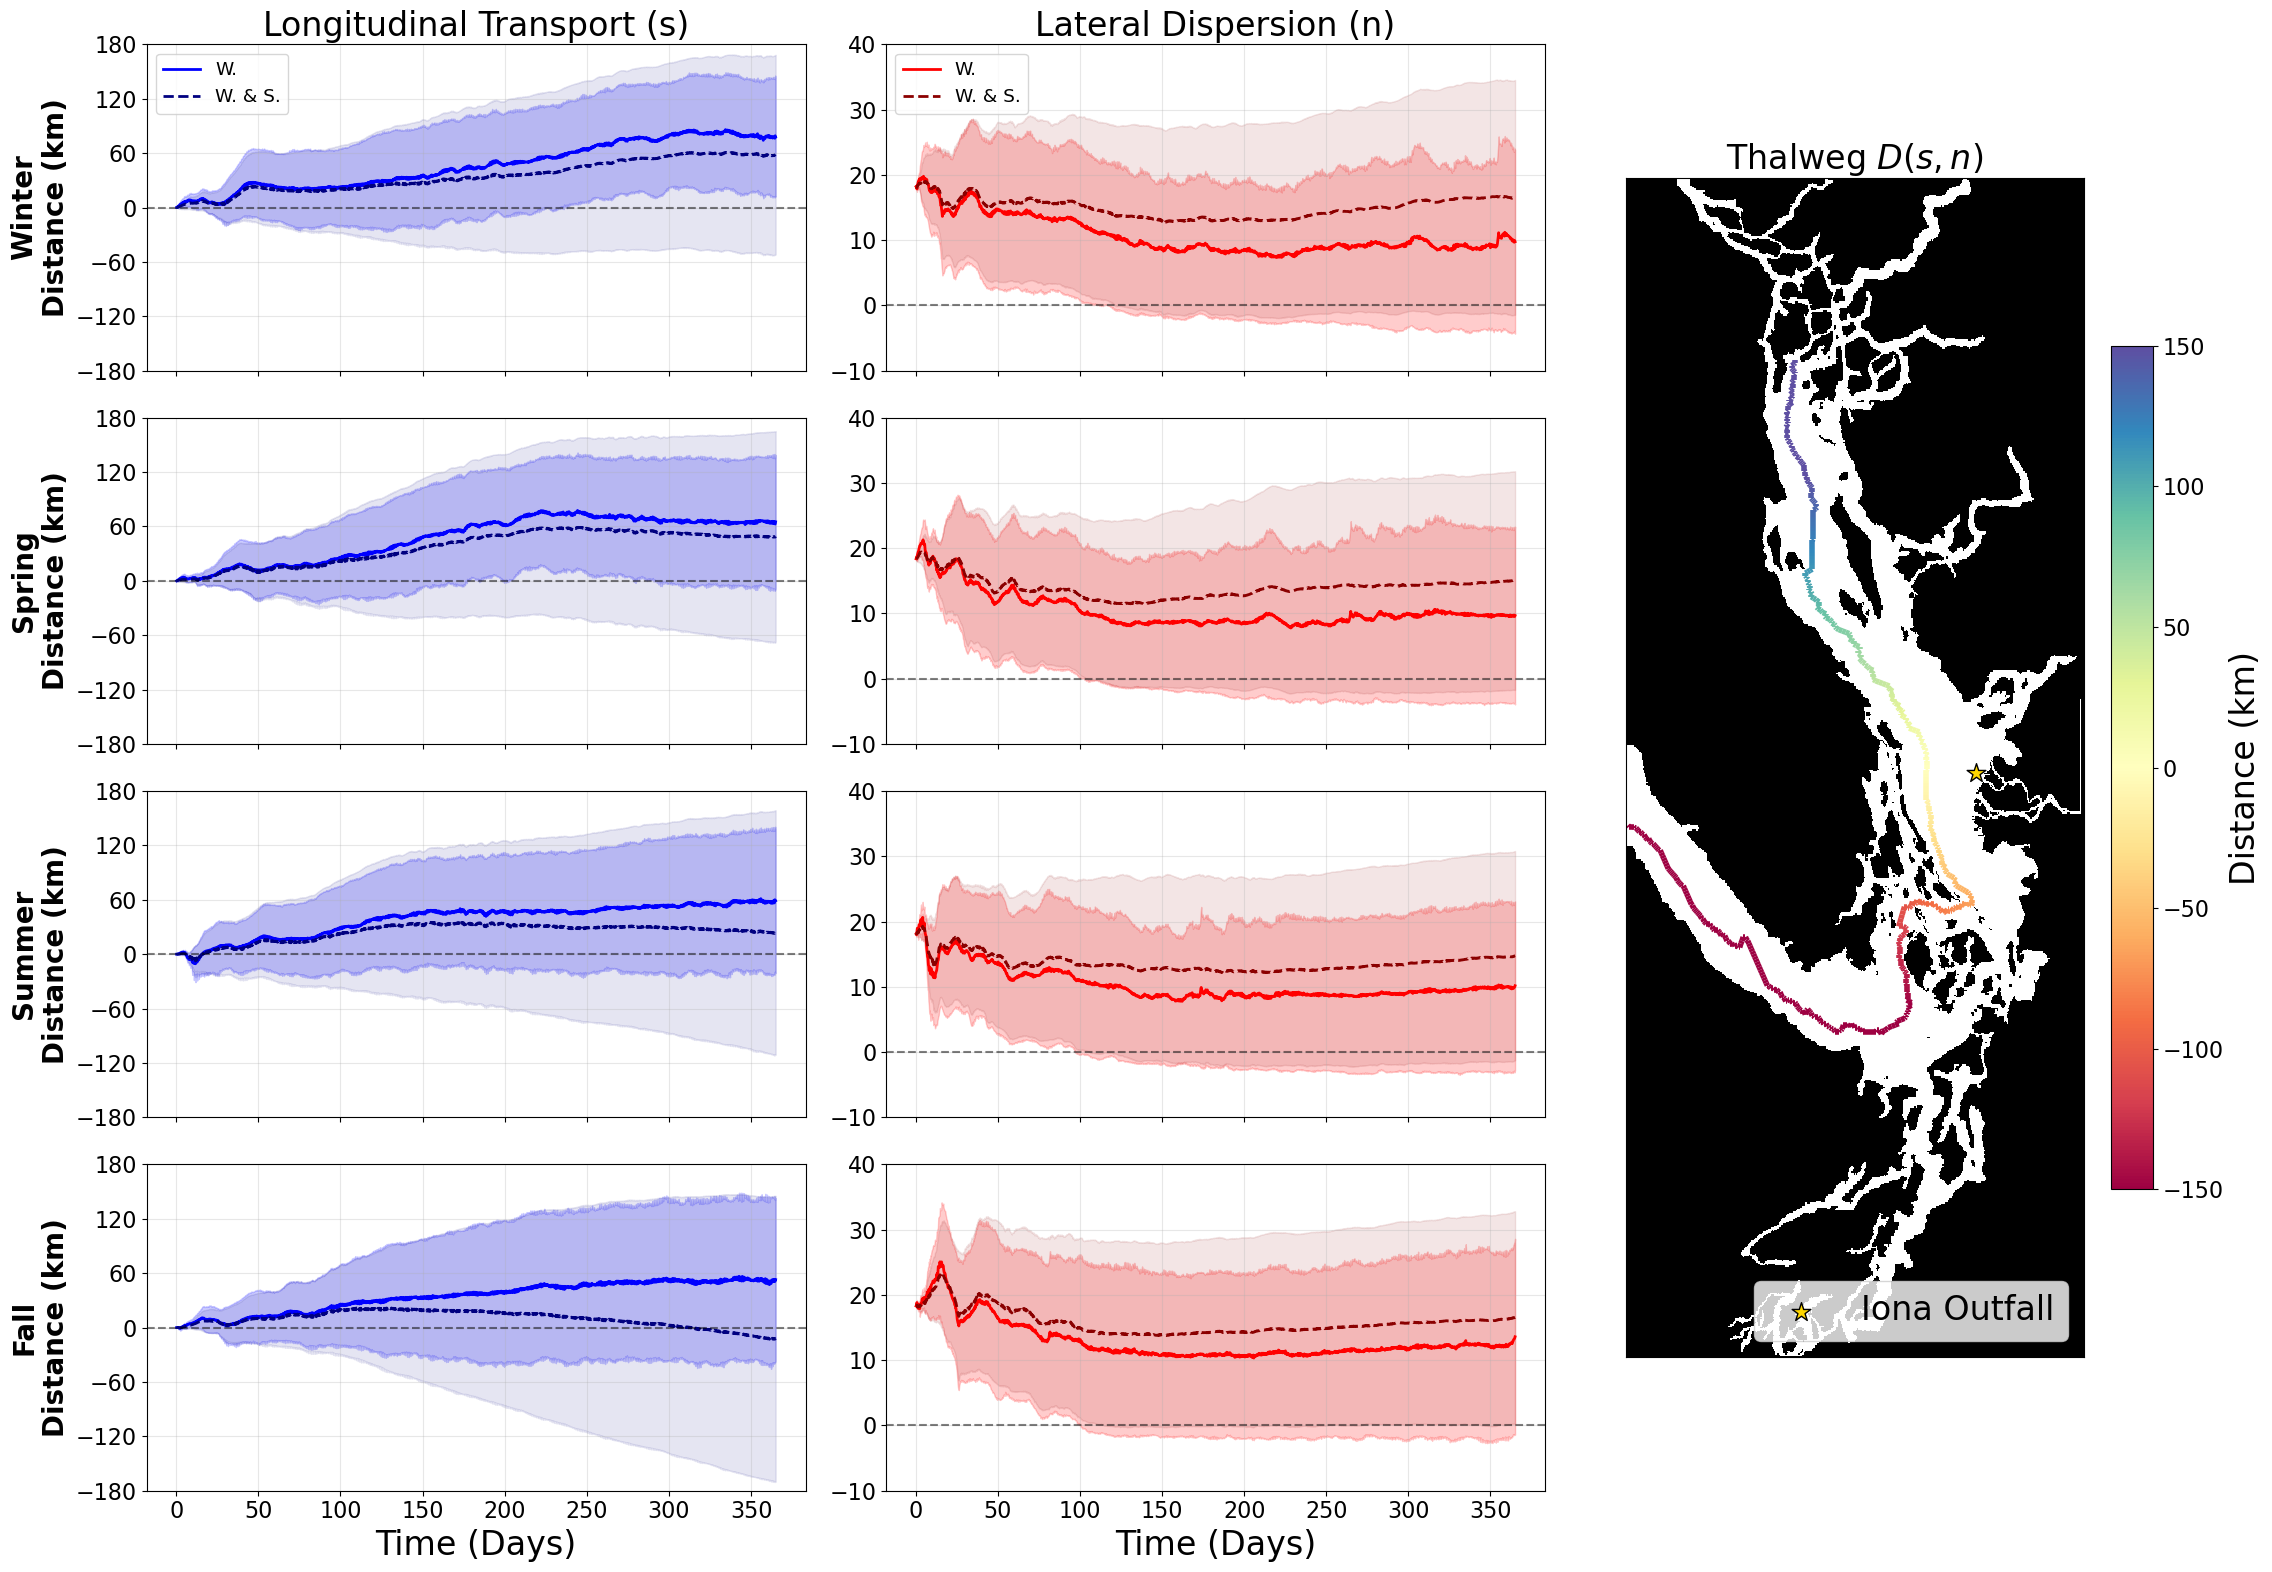

In [32]:
a, b = finder(source_lat,source_lon)
visualize_seasonal_comparison(
    seasonal_results_W, 
    thalweg_lats, 
    thalweg_lons,       # Your latitude grid
    mask['tmask'][0][0],
    thalweg, [a,b],
    seasonal_results_W_S
)

In [33]:
def visualize_trajectory(seasonal_results, sediment_results=None, window_size=24):
    """
    Plots the Center of Mass trajectory (Lateral N vs Longitudinal S).
    Includes smoothing to visualize the path clearly.
    
    Args:
        seasonal_results: Dict of results tuples for Water
        sediment_results: Optional Dict of results tuples for Sediment
        window_size: Number of time steps for moving average smoothing
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Colors matching the user's request
    styles = {
        'Winter': {'c': 'k', 'label': 'Winter'},
        'Spring': {'c': 'g', 'label': 'Spring'},
        'Summer': {'c': 'b', 'label': 'Summer'},
        'Fall':   {'c': 'r', 'label': 'Fall'}
    }
    
    # Plot Trajectories
    for season, style in styles.items():
        c = style['c']
        
        # --- WATER (Solid) ---
        if season in seasonal_results:
            mean_S, std_S, mean_N, std_N = seasonal_results[season]
            
            # 1. Remove NaNs
            valid = np.isfinite(mean_S) & np.isfinite(mean_N)
            S_clean = mean_S[valid]
            N_clean = mean_N[valid]
            
            if len(S_clean) >= window_size:
                # 2. Smooth
                box = np.ones(window_size) / window_size
                S_smooth = np.convolve(S_clean, box, mode='valid')
                N_smooth = np.convolve(N_clean, box, mode='valid')
                
                # 3. Plot
                ax.plot(N_smooth, S_smooth, color=c, lw=2, linestyle='-', label=season)
                
                # 4. Markers
                ax.scatter(N_smooth[0], S_smooth[0], marker='*', c=c, s=200, edgecolors='y', zorder=3)
                ax.scatter(N_smooth[-1], S_smooth[-1], marker='o', c=c, s=200, edgecolors='y', zorder=3)

        # --- SEDIMENT (Dashed) ---
        if sediment_results and season in sediment_results:
            mean_S_sed, std_S_sed, mean_N_sed, std_N_sed = sediment_results[season]
            
            # 1. Remove NaNs
            valid_sed = np.isfinite(mean_S_sed) & np.isfinite(mean_N_sed)
            S_clean_sed = mean_S_sed[valid_sed]
            N_clean_sed = mean_N_sed[valid_sed]
            
            if len(S_clean_sed) >= window_size:
                # 2. Smooth
                box = np.ones(window_size) / window_size
                S_smooth_sed = np.convolve(S_clean_sed, box, mode='valid')
                N_smooth_sed = np.convolve(N_clean_sed, box, mode='valid')
                
                # 3. Plot (Dashed)
                ax.plot(N_smooth_sed, S_smooth_sed, color=c, lw=2, linestyle='--')
                
                # 4. Markers
                ax.scatter(N_smooth_sed[0], S_smooth_sed[0], marker='*', c=c, s=200, edgecolors='y', zorder=3)
                ax.scatter(N_smooth_sed[-1], S_smooth_sed[-1], marker='o', c=c, s=200, edgecolors='y', zorder=3)

    # --- Add Styles to Legend ---
    # Get existing handles (Seasons)
    handles, labels = ax.get_legend_handles_labels()
    
    # Create generic handles for Water vs Sediment
    line_water = Line2D([0], [0], color='gray', lw=2, linestyle='-', label='W.')
    line_sed = Line2D([0], [0], color='gray', lw=2, linestyle='--', label='W. & S.')
    
    # Combine and Plot
    handles.extend([line_water, line_sed])
    ax.legend(handles=handles, loc='best')

    ax.axvline(0, color='k', linestyle='--', alpha=0.3)
    ax.axhline(0, color='k', linestyle='--', alpha=0.3)
    
    ax.set_xlabel('Mean Lateral Distance (km)\n(Negative = West / Positive = East)', fontsize=12)
    ax.set_ylabel('Mean Longitudinal Distance (km)\n(Negative = South / Positive = North)', fontsize=12)
    ax.set_title('Center of Mass Trajectory (Smoothed)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    #ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

In [34]:
def visualize_trajectory(seasonal_results, sediment_results=None, window_size=24):
    """
    Plots the Center of Mass trajectory in a 2x2 layout, one subplot per season.
    Visualizes:
    - Mean Trajectory (Solid for Water, Dashed for Sediment)
    - Mean + Std (Dotted for Water, Dash-Dot for Sediment)
    - Mean - Std (Dotted for Water, Dash-Dot for Sediment)
    
    Args:
        seasonal_results: Dict of results tuples for Water
        sediment_results: Optional Dict of results tuples for Sediment
        window_size: Number of time steps for moving average smoothing
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()
    
    # Season Order Mapping
    seasons = ['Winter', 'Spring', 'Summer', 'Fall']
    colors = {'Winter': 'k', 'Spring': 'g', 'Summer': 'b', 'Fall': 'r'}
    
    # --- Helper to smooth and plot ---
    def plot_on_ax(ax, s_arr, n_arr, c, label, linestyle, marker=False):
        # 1. Remove NaNs
        valid = np.isfinite(s_arr) & np.isfinite(n_arr)
        s_clean = s_arr[valid]
        n_clean = n_arr[valid]
        
        if len(s_clean) >= window_size:
            # 2. Smooth
            box = np.ones(window_size) / window_size
            s_smooth = np.convolve(s_clean, box, mode='valid')
            n_smooth = np.convolve(n_clean, box, mode='valid')
            
            # 3. Plot
            ax.plot(n_smooth, s_smooth, color=c, lw=2, linestyle=linestyle, label=label)
            
            # 4. Markers (Start/End) - Only for Mean lines usually, or handled by caller
            if marker:
                ax.scatter(n_smooth[0], s_smooth[0], marker='*', c=c, s=200, edgecolors='y', zorder=3)
                ax.scatter(n_smooth[-1], s_smooth[-1], marker='o', c=c, s=200, edgecolors='y', zorder=3)

    # --- MAIN LOOP ---
    for i, season in enumerate(seasons):
        ax = axes[i]
        c = colors[season]
        
        has_data = False
        
        # --- WATER (Mean=Solid, Std=Dotted) ---
        if season in seasonal_results:
            has_data = True
            mS, sS, mN, sN = seasonal_results[season]
            
            # Mean
            plot_on_ax(ax, mS, mN, c, "Mean (W.)", '-', marker=True)
            # Mean + Std
            plot_on_ax(ax, mS + sS, mN + sN, c, "±1 Std (W.)", ':', marker=False)
            # Mean - Std
            plot_on_ax(ax, mS - sS, mN - sN, c, None, ':', marker=False)

        # --- SEDIMENT (Mean=Dashed, Std=Dash-Dot) ---
        if sediment_results and season in sediment_results:
            has_data = True
            mS, sS, mN, sN = sediment_results[season]
            
            # Mean
            plot_on_ax(ax, mS, mN, c, "Mean (W. & S.)", '--', marker=True)
            # Mean + Std
            plot_on_ax(ax, mS + sS, mN + sN, c, "±1 Std (W. & S.)", '-.', marker=False)
            # Mean - Std
            plot_on_ax(ax, mS - sS, mN - sN, c, None, '-.', marker=False)

        # --- FORMATTING ---
        ax.set_title(f"{season} Trajectories", fontsize=18, fontweight='bold')
        ax.axvline(0, color='k', linestyle=':', alpha=0.8)
        ax.axhline(0, color='k', linestyle=':', alpha=0.8)
        ax.grid(True, alpha=0.3)
        #ax.set_aspect('equal')
        
        ax.set_xlabel('Lateral Distance (n) [km]', fontsize=18)
        ax.set_ylabel('Longitudinal Distance (s) [km]', fontsize=18)
        ax.set_ylim(-170,170); ax.set_xlim(-10,40)
        # Unique Legend
        if has_data:
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='best', fontsize=18)

    plt.tight_layout()
    plt.show()

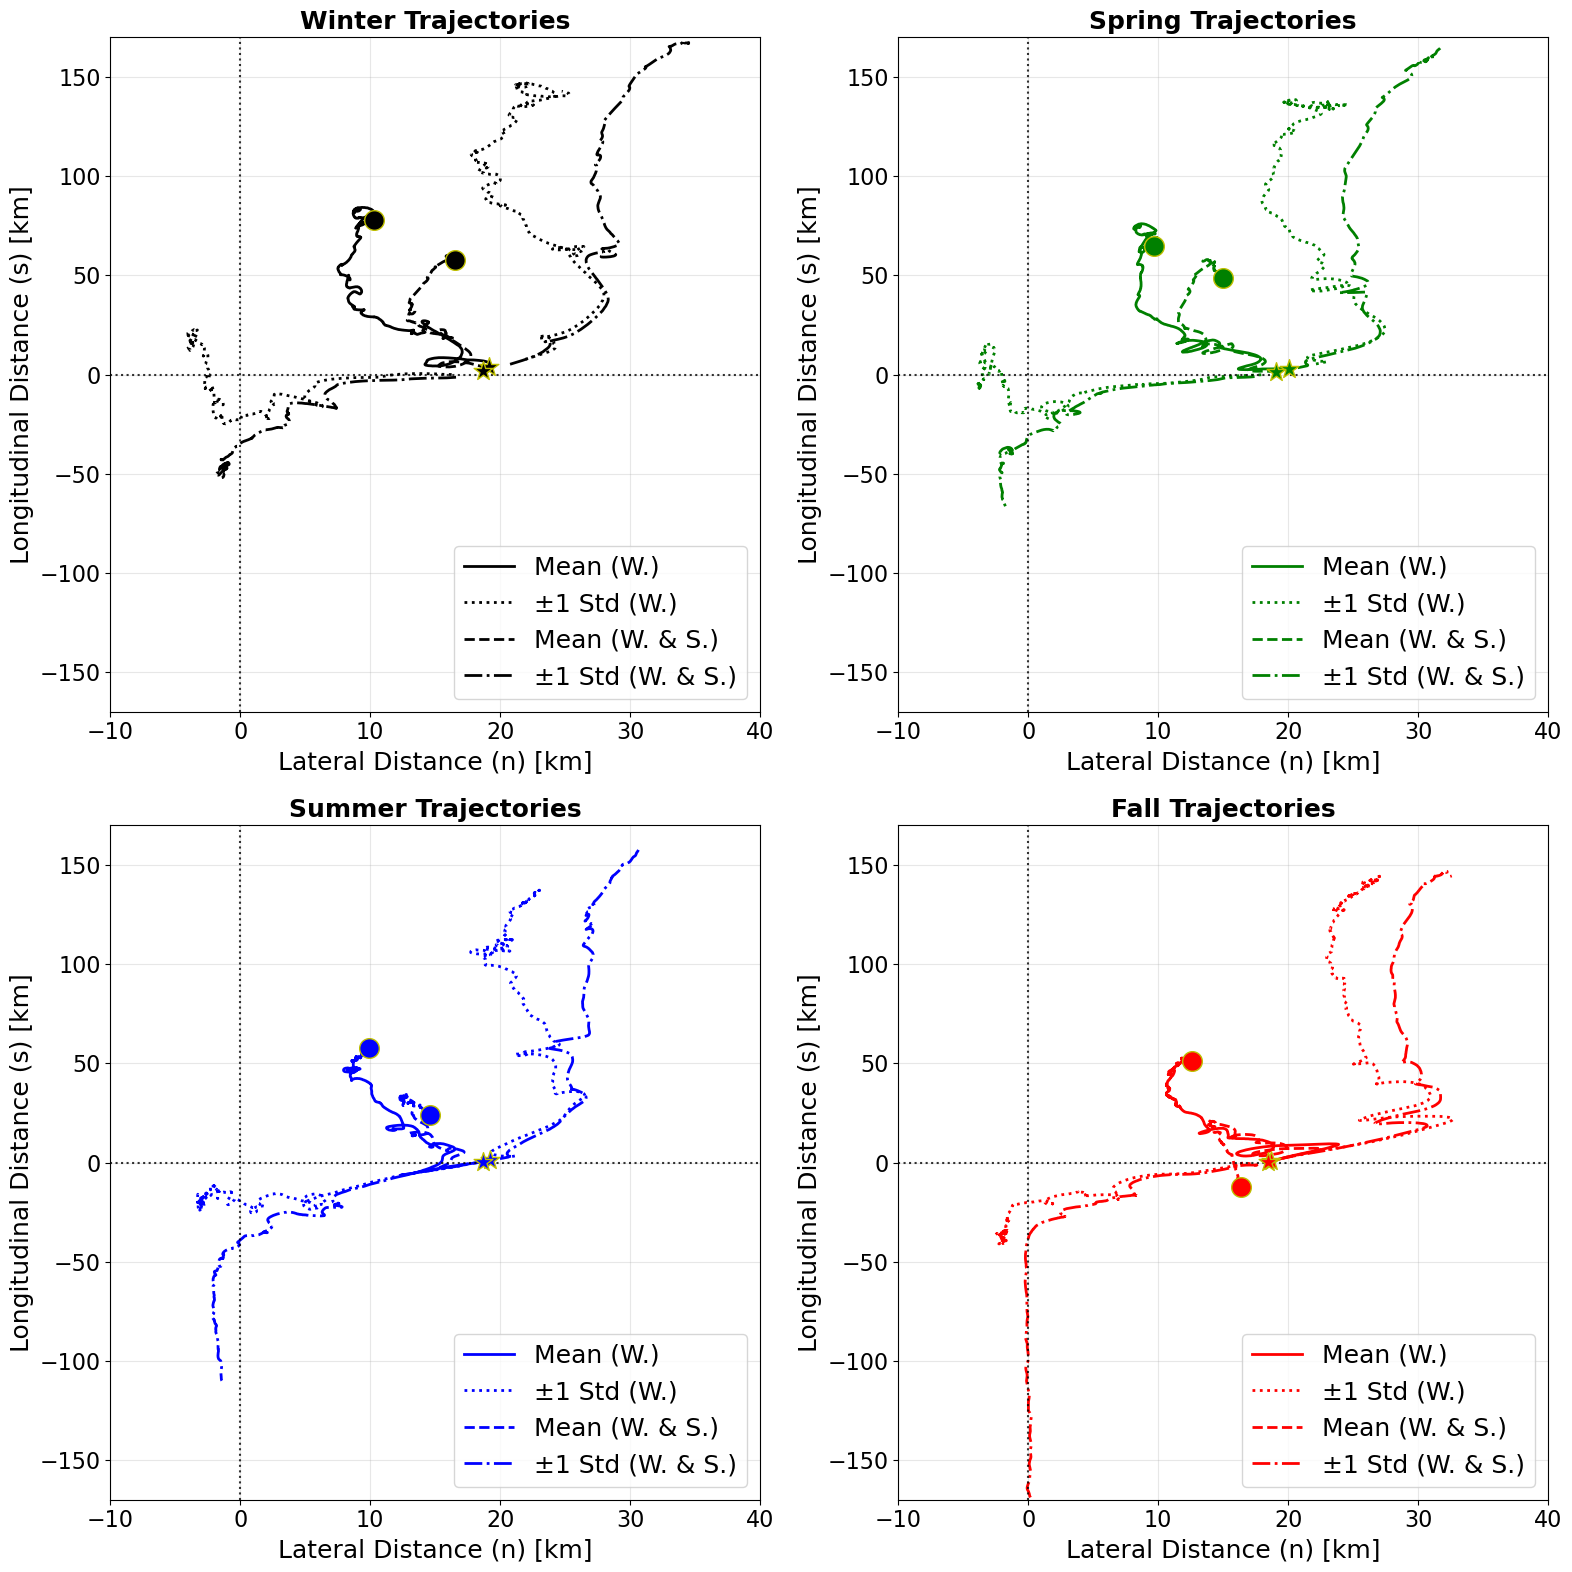

In [35]:
visualize_trajectory(seasonal_results_W, seasonal_results_W_S, window_size=24)

In [57]:
from scipy.interpolate import interp1d
def visualize_trajectories_on_map_V1(seasonal_results, 
                                  thalweg_lats, thalweg_lons, thalweg_indices,
                                  mask_land, source_indices, string,
                                  sediment_results=None,
                                  source_lat=49.195045, source_lon=-123.301956,
                                  window_size=12,
                                  seasons_order=['Winter', 'Spring', 'Summer', 'Fall']):
    #
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(source_lat))
    t_y_km = thalweg_lats * DEG_TO_KM
    t_x_km = thalweg_lons * DEG_TO_KM * lat_scale
    
    dy = np.diff(t_y_km)
    dx = np.diff(t_x_km)
    s_vals_km = np.concatenate(([0], np.cumsum(np.sqrt(dy**2 + dx**2))))
    
    tree = cKDTree(np.column_stack((t_y_km, t_x_km)))
    src_y_km = source_lat * DEG_TO_KM
    src_x_km = source_lon * DEG_TO_KM * lat_scale
    _, src_idx = tree.query([[src_y_km, src_x_km]])
    s_source_km = s_vals_km[src_idx[0]]
    
    thalweg_starts_north = thalweg_lats[0] > thalweg_lats[-1]
    
    interp_y = interp1d(s_vals_km, thalweg_indices[:, 0], kind='linear', fill_value="extrapolate")
    interp_x = interp1d(s_vals_km, thalweg_indices[:, 1], kind='linear', fill_value="extrapolate")
    
    def get_grid_trajectory(mean_S_arr):
        if thalweg_starts_north:

            s_absolute = s_source_km - mean_S_arr
        else:

            s_absolute = s_source_km + mean_S_arr
            
        traj_y = interp_y(s_absolute)
        traj_x = interp_x(s_absolute)
        return traj_y, traj_x

    def smooth(arr, w):
        if len(arr) < w: return arr
        box = np.ones(w)/w
        return np.convolve(arr, box, mode='valid')

    fig, axes = plt.subplots(1, 4, figsize=(20, 10))
    axes = axes.flatten()
    colors = {'Winter': 'k', 'Spring': 'g', 'Summer': 'b', 'Fall': 'r'}
    
    colors_mask = [(0, 0, 0, 1), (0, 0, 0, 0)]
    cmap_land = ListedColormap(colors_mask)

    for i, season in enumerate(seasons_order):
        ax = axes[i]
        c = colors[season]
        
        ax.pcolormesh(mask_land, cmap=cmap_land, shading='auto', zorder=1)
        ax.plot(thalweg_indices[:, 1], thalweg_indices[:, 0], color='gray', lw=3, alpha=0.5,)
        
        src_y, src_x = source_indices
        ax.scatter(src_x, src_y, c='gold', s=150, marker='*', edgecolors='k', zorder=5, label='Source')
        
        has_data = False
        
        def plot_series(S_raw, Std_raw, style, label_suffix = string):
            valid = np.isfinite(S_raw) & np.isfinite(Std_raw)
            S_clean = S_raw[valid]
            Std_clean = Std_raw[valid]
            
            if len(S_clean) > window_size:
                # Smooth S, S+Std, S-Std
                S_mean_sm = smooth(S_clean, window_size)
                S_plus_sm = smooth(S_clean + Std_clean, window_size)
                S_minus_sm = smooth(S_clean - Std_clean, window_size)
                
                y_m, x_m = get_grid_trajectory(S_mean_sm)
                y_p, x_p = get_grid_trajectory(S_plus_sm)
                y_n, x_n = get_grid_trajectory(S_minus_sm)
                
                # + Std (Front)
                ax.plot(x_p, y_p, color='tab:orange', lw=4, linestyle=style, alpha=0.8, label=f'+Std {label_suffix}')
                # - Std (Back)
                ax.plot(x_n, y_n, color='c', lw=4, linestyle=style, alpha=0.8, label=f'-Std {label_suffix}')
                # Mean
                ax.plot(x_m, y_m, color=c, lw=6, linestyle=style, label=f'Mean {label_suffix}')                
                # Markers on Mean
                ax.scatter(x_m[0], y_m[0], c=c, marker='*', s=150, edgecolors='y', zorder=4, label = 'Thalweg Initial Point')
                ax.scatter(x_m[-1], y_m[-1], c=c, marker='o', s=150, edgecolors='white', zorder=4, label = 'Thalweg End Point')
                return True
            return False

        # Water
        if season in seasonal_results:
            mS, sS, _, _ = seasonal_results[season]
            if plot_series(mS, sS, '-'): has_data = True

        # Sediment
        if sediment_results and season in sediment_results:
            mS_sed, sS_sed, _, _ = sediment_results[season]
            if plot_series(mS_sed, sS_sed, '--', '(Sediment)'): has_data = True

        ax.set_title(f"{season} Longitudinal Spread", fontsize=14, fontweight='bold')
        ax.set_aspect('equal')
        
        if has_data:
            # 
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower right', fontsize='small')
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [77]:
def visualize_trajectories_on_map_V2(seasonal_results, 
                                  thalweg_lats, thalweg_lons, thalweg_indices,
                                  mask_land, source_indices, string='',
                                  sediment_results=None,
                                  source_lat=49.195045, source_lon=-123.301956,
                                  window_size=12,
                                  seasons_order=['Winter', 'Spring', 'Summer', 'Fall']):
    """
    Plots the longitudinal dispersion bounds (+Std and -Std) DIRECTLY on the Thalweg (N=0).
    LINES are colored by TIME (Days) to visualize temporal progression.
    Mean trajectory is NOT plotted, but Start/End markers are placed at the Mean location.
    """
    
    # --- 1. PRE-CALCULATE THALWEG MAPPING ---
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(source_lat))
    t_y_km = thalweg_lats * DEG_TO_KM
    t_x_km = thalweg_lons * DEG_TO_KM * lat_scale
    
    dy = np.diff(t_y_km)
    dx = np.diff(t_x_km)
    s_vals_km = np.concatenate(([0], np.cumsum(np.sqrt(dy**2 + dx**2))))
    
    tree = cKDTree(np.column_stack((t_y_km, t_x_km)))
    src_y_km = source_lat * DEG_TO_KM
    src_x_km = source_lon * DEG_TO_KM * lat_scale
    _, src_idx = tree.query([[src_y_km, src_x_km]])
    s_source_km = s_vals_km[src_idx[0]]
    
    thalweg_starts_north = thalweg_lats[0] > thalweg_lats[-1]
    
    # FIX: Remove duplicates for interpolation
    _, unique_idx = np.unique(s_vals_km, return_index=True)
    unique_idx = np.sort(unique_idx)
    s_vals_clean = s_vals_km[unique_idx]
    indices_clean = thalweg_indices[unique_idx]

    interp_y = interp1d(s_vals_clean, indices_clean[:, 0], kind='cubic', fill_value="extrapolate")
    interp_x = interp1d(s_vals_clean, indices_clean[:, 1], kind='cubic', fill_value="extrapolate")
    
    # --- Source Side Detection for Normal Vector ---
    y0_g, x0_g = thalweg_indices[0]
    y1_g, x1_g = thalweg_indices[min(10, len(thalweg_indices)-1)]
    T_vec = np.array([x1_g-x0_g, y1_g-y0_g])
    S_vec = np.array([source_indices[1]-x0_g, source_indices[0]-y0_g])
    source_is_left = np.cross(T_vec, S_vec) > 0
    normal_sign = 1.0 if source_is_left else -1.0

    def get_offset_coords(s_val, n_offset, delta_km=0.5):
        if thalweg_starts_north:
            s_abs = s_source_km - s_val
        else:
            s_abs = s_source_km + s_val
            
        y0 = interp_y(s_abs)
        x0 = interp_x(s_abs)
        
        y_p = interp_y(s_abs + delta_km)
        x_p = interp_x(s_abs + delta_km)
        y_m = interp_y(s_abs - delta_km)
        x_m = interp_x(s_abs - delta_km)
        
        dy_t = y_p - y_m
        dx_t = x_p - x_m
        
        scale = (n_offset * normal_sign) / (2 * delta_km)
        off_x = scale * (-dy_t)
        off_y = scale * (dx_t)
        return y0 + off_y, x0 + off_x

    def smooth(arr, w):
        if len(arr) < w: return arr
        box = np.ones(w)/w
        return np.convolve(arr, box, mode='valid')

    fig, axes = plt.subplots(1, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    colors_mask = [(0, 0, 0, 1), (0, 0, 0, 0)]
    cmap_land = ListedColormap(colors_mask)

    def plot_colored_line(ax, x, y, t, cmap_name='Reds', style='-', alpha=1.0, linewidth=2):
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        norm = plt.Normalize(0, 365) 
        if t.max() > 365: norm = plt.Normalize(t.min(), t.max())
        
        lc = LineCollection(segments, cmap=cmap_name, norm=norm, linestyles=style, alpha=alpha, linewidth=linewidth)
        lc.set_array(t)
        ax.add_collection(lc)
        return lc

    global_lc = None # For colorbar

    for i, season in enumerate(seasons_order):
        ax = axes[i]
        
        ax.pcolormesh(mask_land, cmap=cmap_land, shading='auto', zorder=1)
        ax.plot(thalweg_indices[:, 1], thalweg_indices[:, 0], color='gray', lw=3, alpha=0.3)
        
        src_y, src_x = source_indices
        ax.scatter(src_x, src_y, c='gold', s=150, marker='*', edgecolors='k', zorder=5, label='Source')
        
        has_data = False
        
        def plot_series(S_raw, Std_S_raw, label_suffix, line_styles=['-', '-', '--']):
            nonlocal global_lc
            valid = np.isfinite(S_raw) & np.isfinite(Std_S_raw)
            S_c = S_raw[valid]
            Std_c = Std_S_raw[valid]
            
            if len(S_c) > window_size:
                S_m = smooth(S_c, window_size)
                S_p = smooth(S_c + Std_c, window_size)
                S_n = smooth(S_c - Std_c, window_size)
                
                # Create Time Array 
                t_arr = np.linspace(0, 365, len(S_m)) 
                
                # Get Coords on Thalweg (N=0)
                ym, xm = [], []
                yp, xp = [], []
                yn, xn = [], []
                
                for s in S_m:
                    y, x = get_offset_coords(s, 0)
                    ym.append(y); xm.append(x)
                for s in S_p:
                    y, x = get_offset_coords(s, 0)
                    yp.append(y); xp.append(x)
                for s in S_n:
                    y, x = get_offset_coords(s, 0)
                    yn.append(y); xn.append(x)
                
                # Plot Colored Lines (+Std and -Std only)
                # +Std (Thin Solid)
                lc_m = plot_colored_line(ax, xp, yp, t_arr, style=line_styles[1], linewidth=8, alpha=0.8)
                # -Std (Thin Dashed)
                plot_colored_line(ax, xn, yn, t_arr, style=line_styles[2], linewidth=8, alpha=0.8)
                
                global_lc = lc_m # Save for colorbar
                
                # Start/End Markers (using Mean position for logical placement)
                ax.scatter(xm[0], ym[0], c='k', marker='*', s=200, zorder=6, edgecolors='white', label='Start')
                ax.scatter(xm[-1], ym[-1], c='k', marker='o', s=200, zorder=6, edgecolors='white', label='End (Center-Mass)')
                
                return True
            return False

        # Water
        if season in seasonal_results:
            mS, sS, _, _ = seasonal_results[season]
            if plot_series(mS, sS, '(Water)', line_styles=['-', '-', '--']): has_data = True

        # Sediment
        if sediment_results and season in sediment_results:
            mS_sed, sS_sed, _, _ = sediment_results[season]
            if plot_series(mS_sed, sS_sed, '(Sediment)', line_styles=[':', ':', ':']): has_data = True

        ax.set_title(f"{season} Spread", fontweight='bold')
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
        
        # Add legend if data exists
        if has_data:
            ax.legend(loc='lower right', fontsize = 18)

    # Colorbar
    if global_lc:
        # Create a background patch for the colorbar to improve visibility
        cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03]) # [left, bottom, width, height]
        # Draw white rectangle behind it manually if needed, or rely on fig background
        # Here we just place the colorbar.
        cbar = fig.colorbar(global_lc, cax=cbar_ax, orientation='horizontal')
        cbar.set_label('Time (Days)')
        
        # To ensure the numbers are readable, we can set the background of the colorbar axes to white
        # though colorbars usually fill their extent. If markers/text are hard to see, 
        # we can adjust the label color or add a bounding box. 
        # Making the tick labels larger or bold can also help.
        #cbar.ax.tick_params(labelsize=10) 
        
        # Optional: Add a white background box BEHIND the colorbar if it overlaps things
        # But here we used a separate axes 'cbar_ax' outside the plots, so it should be clean.

    plt.tight_layout(rect=[0, 0.08, 1, 1]) # Adjust layout to make room for colorbar at bottom
    plt.show()

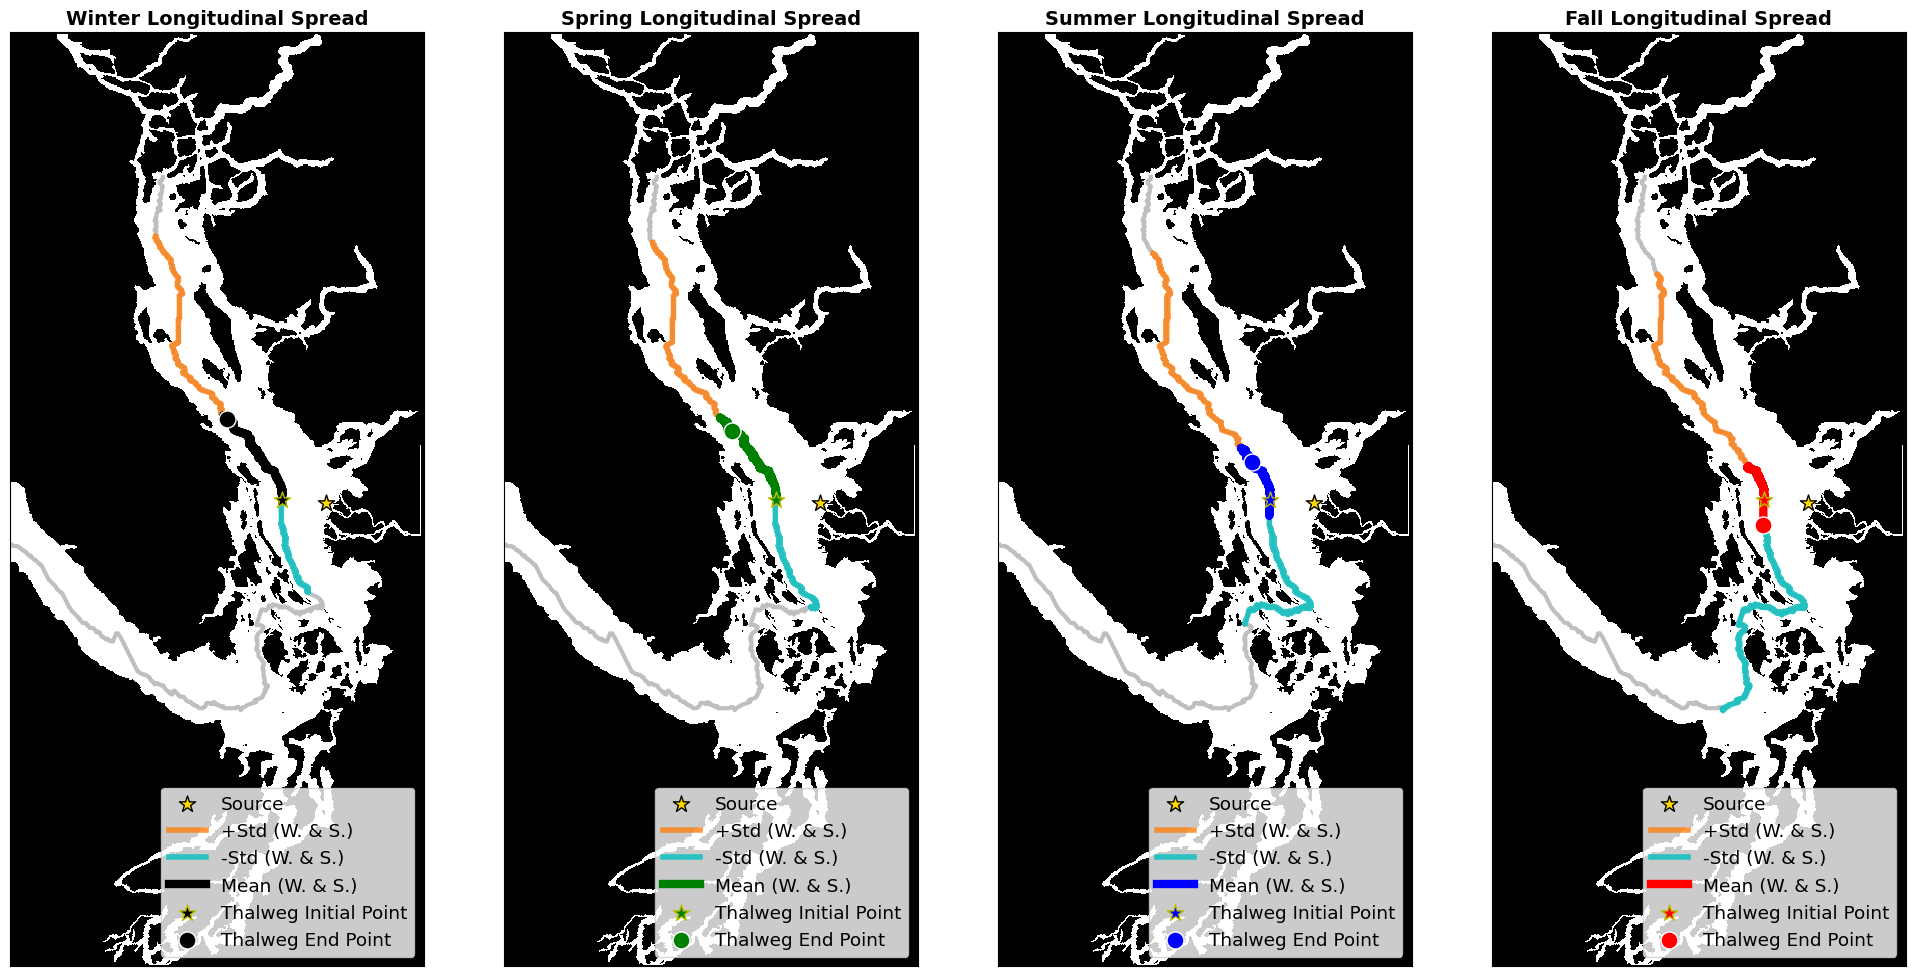

In [59]:
visualize_trajectories_on_map_V1(seasonal_results_W_S, thalweg_lats, thalweg_lons, thalweg, mask['tmask'][0][0],[a,b], string = '(W. & S.)', window_size=1)

/tmp/ipykernel_3316609/263992153.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1]) # Adjust layout to make room for colorbar at bottom


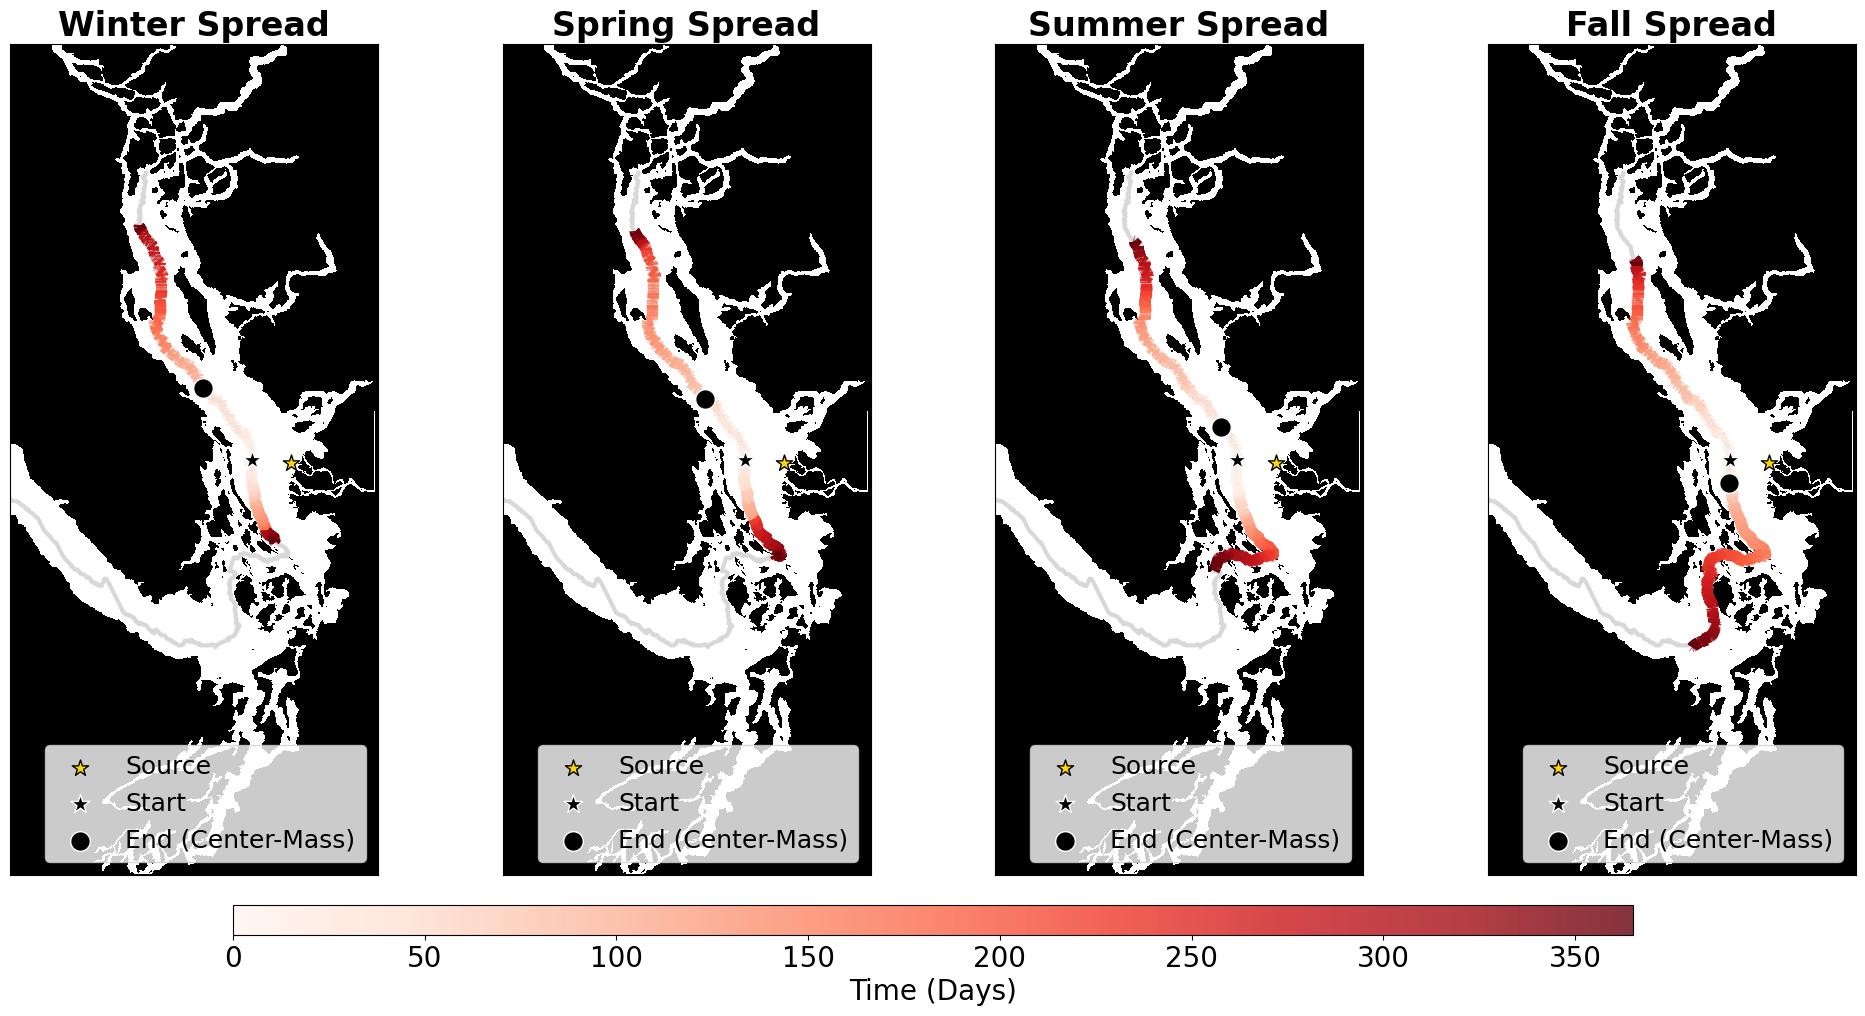

In [78]:
plt.rcParams.update({'font.size': 20})
visualize_trajectories_on_map_V2(seasonal_results_W_S, thalweg_lats, thalweg_lons, thalweg, mask['tmask'][0][0],[a,b], string = '(W. & S.)', window_size=1)

In [50]:
from scipy.ndimage import gaussian_filter1d
def visualize_lateral_dispersion_on_map(seasonal_results, 
                                  thalweg_lats, thalweg_lons, thalweg_indices,
                                  mask_land, source_indices, string,
                                  sediment_results=None,
                                  source_lat=49.195045, source_lon=-123.301956,
                                  window_size=24,
                                  seasons_order=['Winter', 'Spring', 'Summer', 'Fall']):
    #
    DEG_TO_KM = 111.32
    lat_scale = np.cos(np.deg2rad(source_lat))
    t_y_km = thalweg_lats * DEG_TO_KM
    t_x_km = thalweg_lons * DEG_TO_KM * lat_scale
    
    dy = np.diff(t_y_km)
    dx = np.diff(t_x_km)
    s_vals_km = np.concatenate(([0], np.cumsum(np.sqrt(dy**2 + dx**2))))
    
    tree = cKDTree(np.column_stack((t_y_km, t_x_km)))
    src_y_km = source_lat * DEG_TO_KM
    src_x_km = source_lon * DEG_TO_KM * lat_scale
    _, src_idx = tree.query([[src_y_km, src_x_km]])
    s_source_km = s_vals_km[src_idx[0]]
    
    thalweg_starts_north = thalweg_lats[0] > thalweg_lats[-1]
    
    interp_y = interp1d(s_vals_km, thalweg_indices[:, 0], kind='linear', fill_value="extrapolate")
    interp_x = interp1d(s_vals_km, thalweg_indices[:, 1], kind='linear', fill_value="extrapolate")
    
    y0_g, x0_g = thalweg_indices[0]
    y1_g, x1_g = thalweg_indices[min(10, len(thalweg_indices)-1)]
    T_vec = np.array([x1_g-x0_g, y1_g-y0_g])
    S_vec = np.array([source_indices[1]-x0_g, source_indices[0]-y0_g])
    source_is_left = np.cross(T_vec, S_vec) > 0
    normal_sign = 1.0 if source_is_left else -1.0

    def get_offset_coords(s_val, n_offset, delta_km=0.5):
        #    
        if thalweg_starts_north:
            s_abs = s_source_km - s_val
        else:
            s_abs = s_source_km + s_val
            
        y0 = interp_y(s_abs)
        x0 = interp_x(s_abs)
        
        y_p = interp_y(s_abs + delta_km)
        x_p = interp_x(s_abs + delta_km)
        y_m = interp_y(s_abs - delta_km)
        x_m = interp_x(s_abs - delta_km)
        
        dy_t = y_p - y_m
        dx_t = x_p - x_m
        
        scale = (n_offset * normal_sign) / (2 * delta_km)
        
        off_x = scale * (-dy_t)
        off_y = scale * (dx_t)
        
        return y0 + off_y, x0 + off_x

    def smooth(arr, w):
        if len(arr) < w: return arr
        box = np.ones(w)/w
        return np.convolve(arr, box, mode='valid')

    fig, axes = plt.subplots(1, 4, figsize=(20, 10))
    axes = axes.flatten()
    colors = {'Winter': 'k', 'Spring': 'g', 'Summer': 'b', 'Fall': 'r'}
    
    colors_mask = [(0, 0, 0, 1), (0, 0, 0, 0)]
    cmap_land = ListedColormap(colors_mask)

    for i, season in enumerate(seasons_order):
        ax = axes[i]
        c = colors[season]
        
        ax.plot(thalweg_indices[:, 1], thalweg_indices[:, 0], color='gray', lw=3, alpha=0.5,)
        
        src_y, src_x = source_indices
        ax.scatter(src_x, src_y, c='gold', s=150, marker='*', edgecolors='k', zorder=5, label='Source')
        
        has_data = False
        
        def plot_series_with_shade(S_raw, Std_S_raw, Mean_N_raw, Std_N_raw, style, label_suffix = string):
            #    
            valid = np.isfinite(S_raw) & np.isfinite(Std_S_raw) & np.isfinite(Mean_N_raw) & np.isfinite(Std_N_raw)
            S_c = S_raw[valid]
            Std_S_c = Std_S_raw[valid]
            Std_N_c = Std_N_raw[valid]
            
            if len(S_c) > window_size:
                # Smooth
                S_m = smooth(S_c, window_size)
                S_p = smooth(S_c + Std_S_c, window_size)
                S_n = smooth(S_c - Std_S_c, window_size)
                Std_N_sm = smooth(Std_N_c, window_size)
                
                ym, xm = [], []
                yp, xp = [], []
                yn, xn = [], []
                
                for s in S_m:
                    y, x = get_offset_coords(s, 0) #
                    ym.append(y); xm.append(x)
                    
                for s in S_p:
                    y, x = get_offset_coords(s, 0) #
                    yp.append(y); xp.append(x)
                    
                for s in S_n:
                    y, x = get_offset_coords(s, 0) #
                    yn.append(y); xn.append(x)
                
                ax.plot(xp, yp, color='tab:orange', lw=3, linestyle=style, alpha=0.8, label=f'+Std S {label_suffix}')
                ax.plot(xn, yn, color='c', lw=3, linestyle=style, alpha=0.8, label=f'-Std S {label_suffix}')
                ax.plot(xm, ym, color=c, lw=4, linestyle=style, label=f'Mean S {label_suffix}')
                
                ax.scatter(xm[0], ym[0], c=c, marker='*', s=150, edgecolors='y', zorder=4)
                ax.scatter(xm[-1], ym[-1], c=c, marker='o', s=150, edgecolors='white', zorder=4)
                
                def draw_shade_only(s_arr, std_n_arr, color_fill, alpha_val):
                    lx, ly = [], []
                    rx, ry = [], []
                    for s, std_n in zip(s_arr, std_n_arr):
                        y_l, x_l = get_offset_coords(s, std_n)
                        ly.append(y_l); lx.append(x_l)
                        y_r, x_r = get_offset_coords(s, -std_n)
                        ry.append(y_r); rx.append(x_r)
                    px = np.concatenate([lx, rx[::-1]])
                    py = np.concatenate([ly, ry[::-1]])
                    ax.fill(px, py, color=color_fill, alpha=alpha_val,label='_nolegend_', edgecolor = None, hatch = '-')

                draw_shade_only(S_p, Std_N_sm, 'tab:orange', 0.4)
                draw_shade_only(S_n, Std_N_sm, 'c', 0.4)
                draw_shade_only(S_m, Std_N_sm, c, 0.4)
                #
                ax.pcolormesh(mask_land, cmap=cmap_land, shading='auto', zorder=1)


                return True
            return False

        # Water
        if season in seasonal_results:
            mS, sS, mN, sN = seasonal_results[season]
            if plot_series_with_shade(mS, sS, mN, sN, '-'): has_data = True

        # Sediment
        if sediment_results and season in sediment_results:
            mS_sed, sS_sed, mN_sed, sN_sed = sediment_results[season]
            if plot_series_with_shade(mS_sed, sS_sed, mN_sed, sN_sed, '--', '(Sediment)'): has_data = True

        ax.set_title(f"{season} Trajectory & Dispersion", fontsize=14, fontweight='bold')
        ax.set_aspect('equal')
        
        if has_data:
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower right', fontsize='small')
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

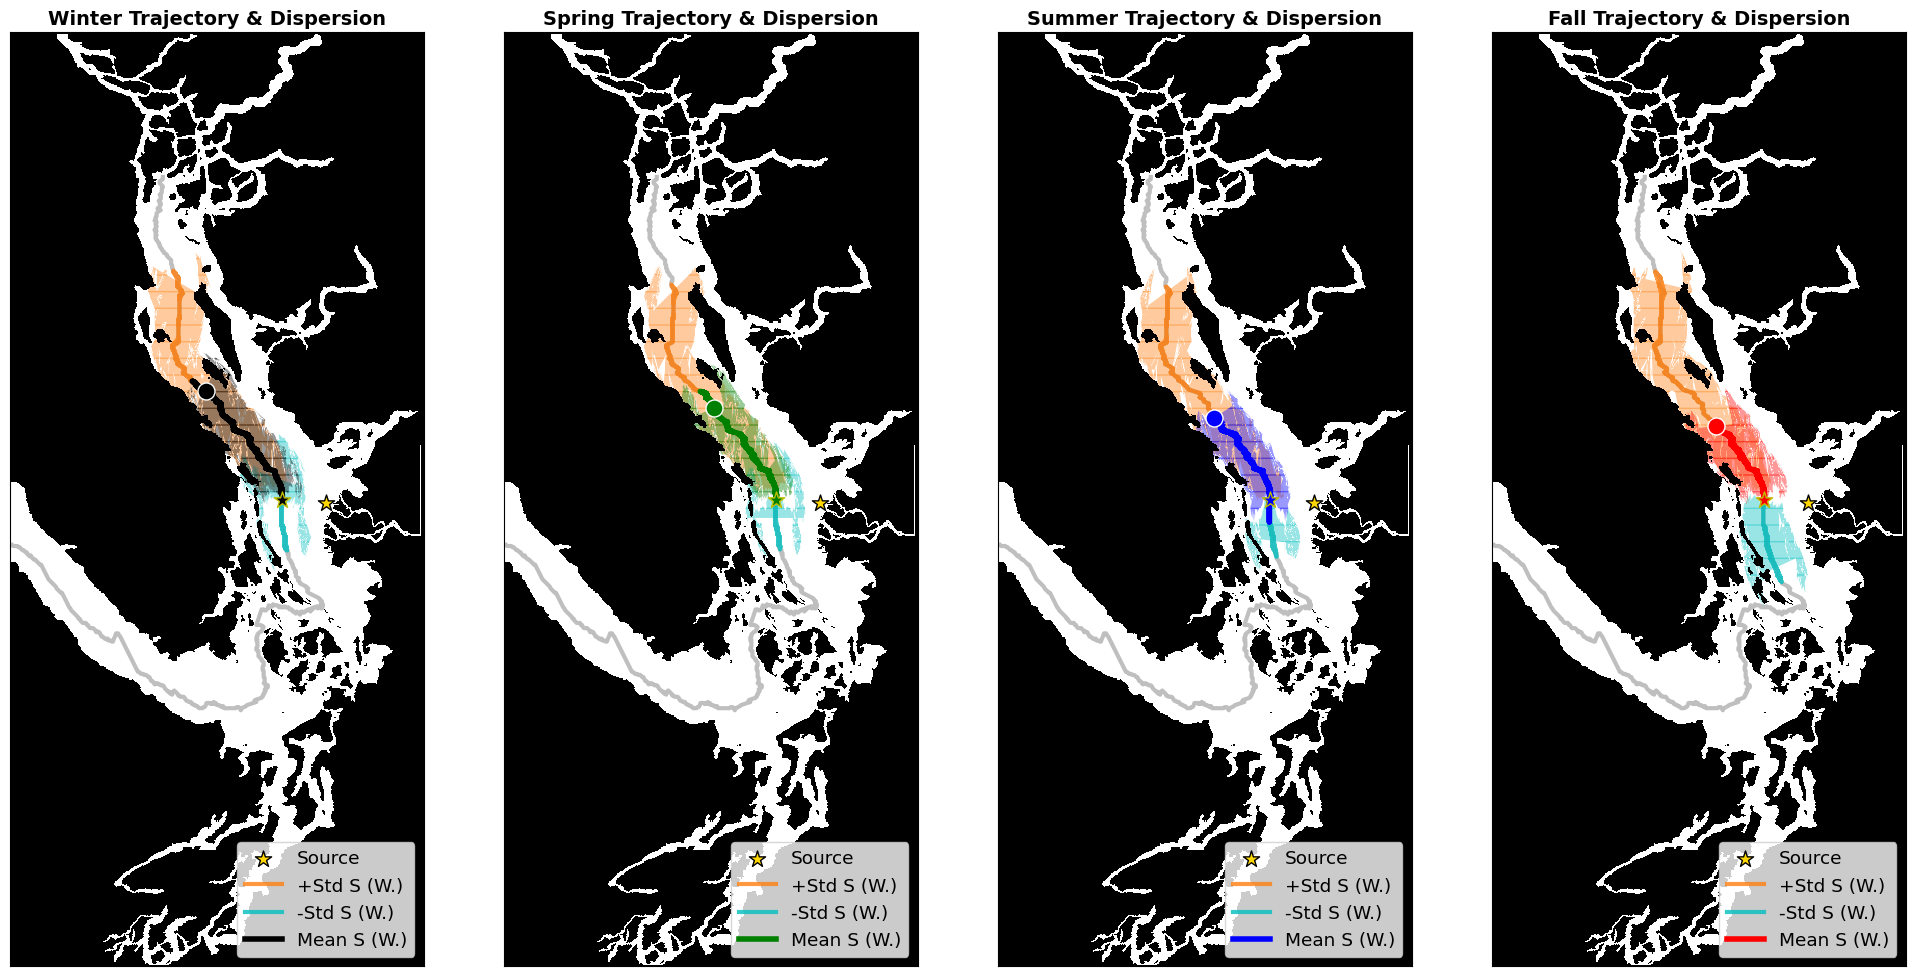

In [51]:
visualize_lateral_dispersion_on_map(seasonal_results_W, thalweg_lats, thalweg_lons, thalweg, mask['tmask'][0][0],[a,b], window_size=1, string = '(W.)')

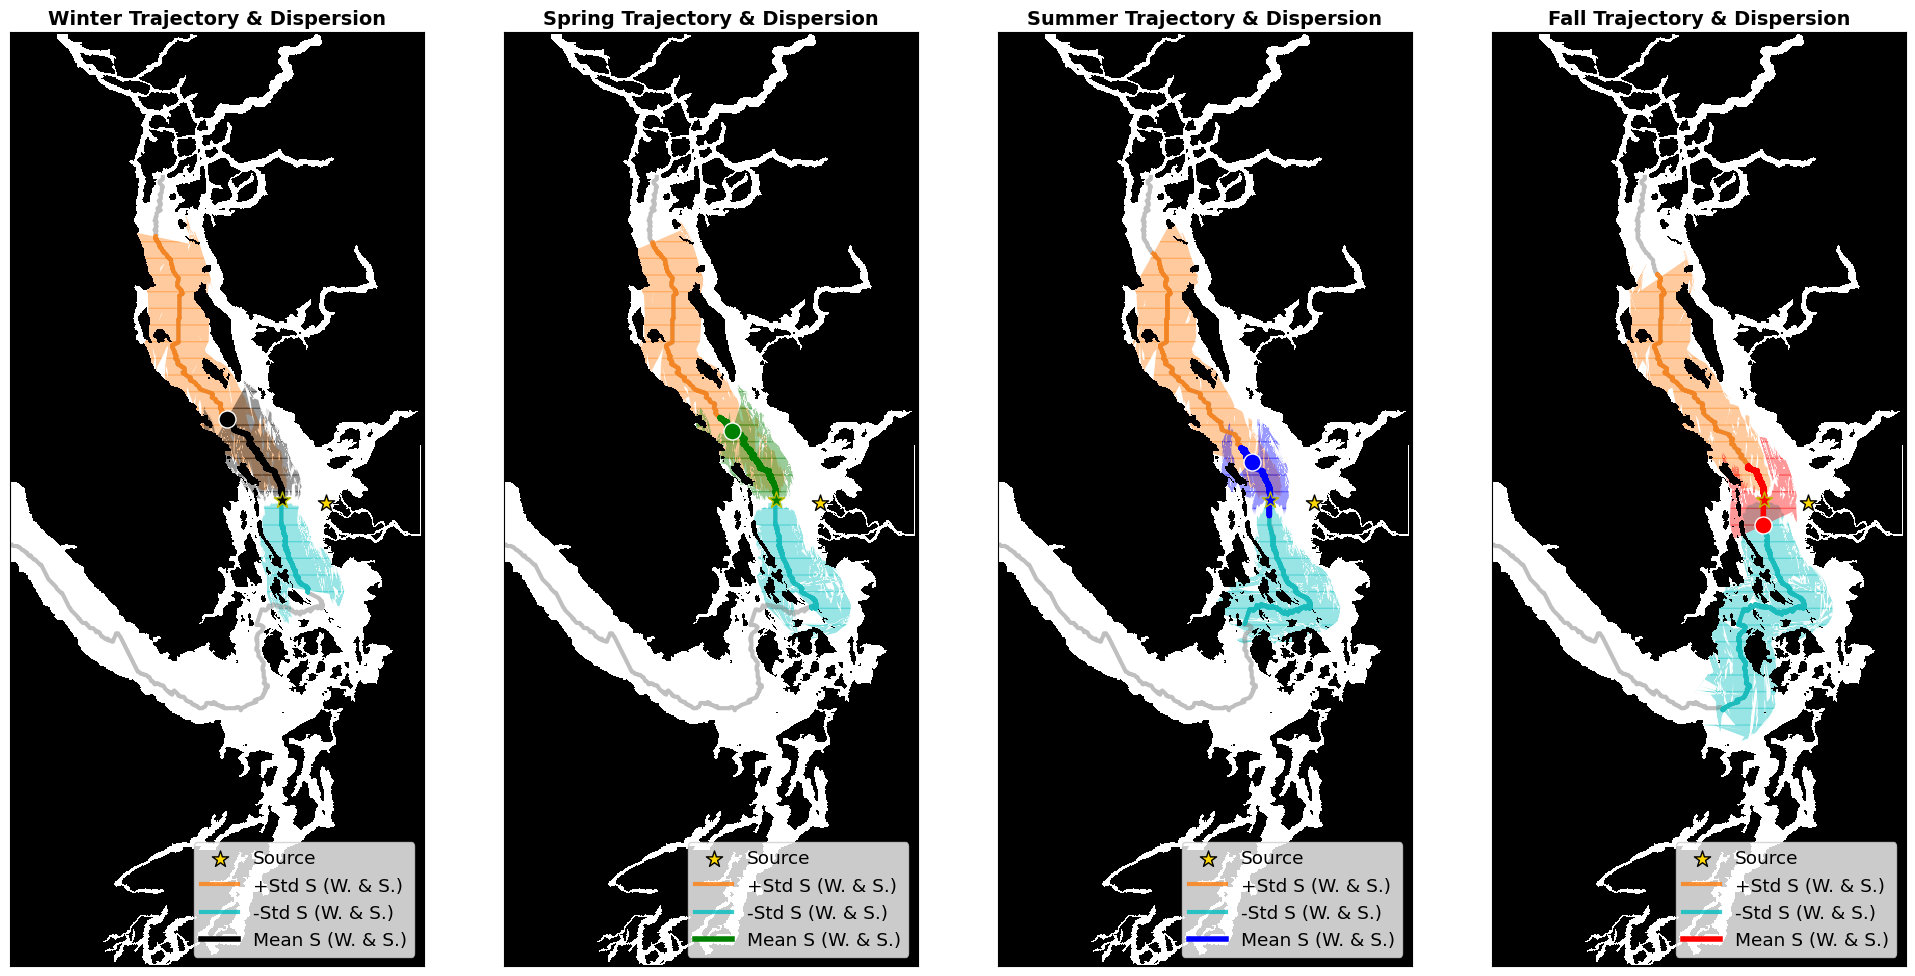

In [41]:
visualize_lateral_dispersion_on_map(seasonal_results_W_S, thalweg_lats, thalweg_lons, thalweg, mask['tmask'][0][0],[a,b], window_size=1, string = '(W. & S.)')

-------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
import numpy as np

# 1. Vectorized Haversine Function
def haversine_vectorized(lat1, lon1, lat2_array, lon2_array):
    """
    Calculates distance in Kilometers between a source point 
    and an array of destination points.
    """
    R = 6371.0  # Earth radius in kilometers

    # Convert degrees to radians
    lat1, lon1 = np.radians([lat1, lon1])
    lat2_array, lon2_array = np.radians([lat2_array, lon2_array])

    dlat = lat2_array - lat1
    dlon = lon2_array - lon1

    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2_array) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# --- Setup Data (Based on your snippet) ---
lat_source = 49.195045
lon_source = -123.301956

# Assuming data['lat'] is shape (num_particles, num_timesteps)
num_timesteps = data['lat'].shape[1] 

mean_distances = []
std_distances = []

# --- 2. Calculate Stats for Time Series ---
for t in range(num_timesteps):
    # Extract all particle positions at time t
    current_lats = data['lat'][:, t].values
    current_lons = data['lon'][:, t].values
    
    # Calculate distances for ALL particles at this timestep at once
    # This returns an array of distances (one per particle)
    distances = haversine_vectorized(lat_source, lon_source, current_lats, current_lons)
    
    # Calculate Mean and Std
    mean_distances.append(np.nanmean(distances)) # nanmean handles missing data safely
    std_distances.append(np.nanstd(distances))

# Convert results to arrays for easier plotting later
mean_distances = np.array(mean_distances)
std_distances = np.array(std_distances)

print(f"Time step 10 Mean: {mean_distances[10]:.2f} km")
print(f"Time step 10 Std:  {std_distances[10]:.2f} km")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ... (Assuming mean_distances and std_distances are already calculated from the previous step) ...

# Create an array for the x-axis (time steps)
time_steps = np.arange(len(mean_distances))

plt.figure(figsize=(10, 6))

# 1. Plot the Mean Line
plt.plot(time_steps, mean_distances, label='Mean Distance', color='#007acc', linewidth=2)

# 2. Shade the Standard Deviation area
# This creates the "cloud" around the mean showing how spread out particles are
plt.fill_between(time_steps, 
                 mean_distances - std_distances, 
                 mean_distances + std_distances, 
                 color='#007acc', alpha=0.3, label='Standard Deviation (Dispersion)')

# Formatting
plt.title('Average Particle Distance from Source Over Time')
plt.xlabel('Time Step')
plt.ylabel('Distance (km)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
def get_ns_displacement(lat_source, lat_array):
    """
    Calculates the North (+) or South (-) distance in km.
    """
    R = 6371.0  # Earth Radius in km
    
    # Calculate difference in radians
    delta_lat_radians = np.radians(lat_array - lat_source)
    
    # Arc length formula: s = r * theta
    return R * delta_lat_radians

In [ ]:
ns_means = []
ns_stds = []

for t in range(num_timesteps):
    current_lats = data['lat'][:, t].values
    
    # We don't need longitudes for N/S calculations!
    ns_dists = get_ns_displacement(lat_source, current_lats)
    
    ns_means.append(np.nanmean(ns_dists))
    ns_stds.append(np.nanstd(ns_dists))

ns_means = np.array(ns_means)
ns_stds = np.array(ns_stds)

In [ ]:
plt.figure(figsize=(10, 6))

# Zero line (The Source Latitude)
plt.axhline(0, color='black', linewidth=1, linestyle='-', label="Source Latitude")

# Plot Mean Drift
plt.plot(time_steps, ns_means, label='Mean N/S Drift', color='#d62728', linewidth=2)

# Shade the Spread (Std Dev)
plt.fill_between(time_steps, 
                 ns_means - ns_stds, 
                 ns_means + ns_stds, 
                 color='#d62728', alpha=0.2, label='N/S Spread')

plt.title('North-South Displacement Over Time')
plt.xlabel('Time Step')
plt.ylabel('Distance North (km)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Helper Functions ---
def get_displacement_components(lat_source, lon_source, lat_array, lon_array):
    R = 6371.0
    
    # North-South Distance (Simple arc length)
    d_lat = np.radians(lat_array - lat_source)
    dist_ns = R * d_lat
    
    # East-West Distance (Arc length scaled by Cosine of Latitude)
    # We use the average latitude of the particle and source to handle the "shrinking" longitude
    mean_lat = np.radians((lat_array + lat_source) / 2)
    d_lon = np.radians(lon_array - lon_source)
    dist_ew = R * d_lon * np.cos(mean_lat)
    
    return dist_ns, dist_ew

# --- 2. Calculate Stats ---
mean_ns, std_ns = [], []
mean_ew, std_ew = [], []

for t in range(num_timesteps):
    lats = data['lat'][:, t].values
    lons = data['lon'][:, t].values
    
    # Get km displacements for ALL particles at this step
    ns_km, ew_km = get_displacement_components(lat_source, lon_source, lats, lons)
    
    # Store means (Center of Mass) and Stds (Spread)
    mean_ns.append(np.nanmean(ns_km))
    std_ns.append(np.nanstd(ns_km))
    
    mean_ew.append(np.nanmean(ew_km))
    std_ew.append(np.nanstd(ew_km))

# --- 3. Plot the 2D Trajectory ---
plt.figure(figsize=(8, 8))

# Plot the path of the Center of Mass
plt.plot(mean_ew, mean_ns, color='black', linewidth=2, label='Center of Mass Path')

# Add "Cloud" markers at intervals (e.g., every 5th time step) to show spread
# We use error bars: Vertical = N/S spread, Horizontal = E/W spread
# Mark the Source
plt.plot(0, 0, marker='*', color='red', markersize=15, label='Source')

# Formatting
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.axvline(0, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('Distance East/West (km)')
plt.ylabel('Distance North/South (km)')
plt.title('Particle Trajectory and Dispersion')
plt.legend()
plt.grid(True)
plt.axis('equal') # Crucial: ensures 1km North looks same size as 1km East

plt.show()

In [ ]:
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['volume']

In [ ]:
jjii = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [ ]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
# Colormap for mask
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)

In [ ]:
def particles_amount(lons, lats, mask=mask, num_lon=200, num_lat=400):
    #
    lons = np.asarray(lons).astype(float).ravel()
    lats = np.asarray(lats).astype(float).ravel()
    # Create lon-lat bin edges
    lon_edges = np.linspace(mask['nav_lon'].min(), mask['nav_lon'].max(), num_lon + 1)
    lat_edges = np.linspace(mask['nav_lat'].min(), mask['nav_lat'].max(), num_lat + 1)

    # Bin centers
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    results = {}
    raw_hist = {}
    grid_indices = {}  # to store ii_sed and jj_sed


    counts, xedges, yedges = np.histogram2d(
        lons, lats,
        bins=[lon_edges, lat_edges]
    )

    # DataFrame (lat as rows, lon as cols)
    results = pd.DataFrame(
        counts.T,  # shape: (num_lat, num_lon)
        index=lat_centers,
        columns=lon_centers
    )

    Xedges, Yedges = np.meshgrid(lon_centers, lat_centers)  # shape: (num_lat, num_lon)
    ii_sed = np.zeros_like(Xedges, dtype=int)
    jj_sed = np.zeros_like(Xedges, dtype=int)

    for i in range(Xedges.shape[0]):
        for j in range(Xedges.shape[1]):
            jj, ii = finder2(Yedges[i, j], Xedges[i, j], mask)
            ii_sed[i, j] = ii
            jj_sed[i, j] = jj

    grid_indices = (ii_sed, jj_sed)

    return results, raw_hist, grid_indices


In [ ]:
data_1 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [4*7*1]); data_2 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [4*7*2]); data_3 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [4*7*4])
data_4 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [4*7*8]); data_5 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [4*7*16]); data_6 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [4*7*24])
data_7 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [4*7*32]); data_8 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [4*7*48])#; data_9 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [0,4*7*48])
#data_10 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [0,4*7*10]); data_11 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [0,4*7*11]); data_12 = data.where((data.status > 0) & (data.status < 4)).isel(obs= [0,4*7*12])

In [ ]:
amount_1,_,grid_XY_1 = particles_amount(data_1.lon, data_1.lat)
amount_2,_,grid_XY_2 = particles_amount(data_2.lon, data_2.lat)
amount_3,_,grid_XY_3 = particles_amount(data_3.lon, data_3.lat)
amount_4,_,grid_XY_4 = particles_amount(data_4.lon, data_4.lat)
amount_5,_,grid_XY_5 = particles_amount(data_5.lon, data_5.lat)
amount_6,_,grid_XY_6 = particles_amount(data_6.lon, data_6.lat)
amount_7,_,grid_XY_7 = particles_amount(data_7.lon, data_7.lat)
amount_8,_,grid_XY_8 = particles_amount(data_8.lon, data_8.lat)
#amount_9,_,grid_XY_9 = particles_amount(data_9.lon, data_9.lat)
#amount_10,_,grid_XY_10 = particles_amount(data_10.lon, data_10.lat)
#amount_11,_,grid_XY_11 = particles_amount(data_11.lon, data_11.lat)
#amount_12,_,grid_XY_12 = particles_amount(data_12.lon, data_12.lat)

In [ ]:
colors_list = [
    '#d73027',  # bright red
    "#c26b00",  # orange
    "#cbc800",  # yellow
    "#08E200",  # light green
    "#005f29",  # dark green
    "#00a8b7",
    "#0043d3",
    "#9D0061",
    "#9e00b0"              # blue
]

In [ ]:
lat_source = 49.195045
lon_source = -123.301956
y_source, x_source = finder(lat_source, lon_source)

In [ ]:
from matplotlib import colors
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize = (6,12))
cmap_heat = cmocean.thermal
# Filled contours
#ax.contourf(grid_XY_12[0], grid_XY_12[1], amount_12, norm=colors.LogNorm(), colors=colors_list[0], label = 'Week 1')
#ax.contourf(grid_XY_11[0], grid_XY_11[1], amount_11, norm=colors.LogNorm(), colors=colors_list[1], label = 'Week 2')
#ax.contourf(grid_XY_10[0], grid_XY_10[1], amount_10, norm=colors.LogNorm(), colors=colors_list[2], label = 'Week 3')
ax.contourf(grid_XY_8[0], grid_XY_8[1], amount_8, norm=colors.LogNorm(), colors=colors_list[0])
ax.contourf(grid_XY_7[0], grid_XY_7[1], amount_7, norm=colors.LogNorm(), colors=colors_list[1])
ax.contourf(grid_XY_6[0], grid_XY_6[1], amount_6, norm=colors.LogNorm(), colors=colors_list[2])
ax.contourf(grid_XY_5[0], grid_XY_5[1], amount_5, norm=colors.LogNorm(), colors=colors_list[3])
ax.contourf(grid_XY_4[0], grid_XY_4[1], amount_4, norm=colors.LogNorm(), colors=colors_list[4])
ax.contourf(grid_XY_3[0], grid_XY_3[1], amount_3, norm=colors.LogNorm(), colors=colors_list[5])
ax.contourf(grid_XY_2[0], grid_XY_2[1], amount_2, norm=colors.LogNorm(), colors=colors_list[6])
ax.contourf(grid_XY_1[0], grid_XY_1[1], amount_1, norm=colors.LogNorm(), colors=colors_list[7])
#
ax.pcolormesh(mask['tmask'][0][0], cmap=cmap)
source = ax.scatter(x_source, y_source, c = 'y', edgecolor = 'k', marker='*', s = 200, label = 'Iona Outfall')
#
legend_elements = [
    Patch(facecolor=colors_list[0], label='12 months'),
    Patch(facecolor=colors_list[2], label='8 months'),
    Patch(facecolor=colors_list[3], label='6 months'),
    Patch(facecolor=colors_list[4], label='4 months'),
    Patch(facecolor=colors_list[5], label='2 months'),
    Patch(facecolor=colors_list[6], label='1 month'),
    Patch(facecolor=colors_list[7], label='Week 2'),
    Patch(facecolor=colors_list[8], label='Week 1'),
    source
]
ax.legend(handles=legend_elements)

#plt.colorbar(caca)
#plt.show()


Better separate them?

In [ ]:
datasets = [data_1, data_2, data_3, data_4, data_5, data_6, data_7, data_8]

all_counts_north = []
all_counts_south = []
prop_north = []
prop_south = []

for data in datasets:
    #
    lat_vals = data.lat.values.ravel()
    #
    north = lat_vals > lat_source   # True if particle north at each time step
    south = lat_vals < lat_source   # True if particle south at each time step

    # Counts per time step
    count_north = north.sum(axis=0)  # shape: (n_obs,)
    count_south = south.sum(axis=0)

    # Proportions per time step
    total = count_north + count_south
    props_north = count_north / total * 100
    props_south = count_south / total * 100
    #
    prop_north.append(props_north)
    prop_south.append(props_south)    



In [ ]:
prop_north_list = [prop_north[0], prop_north[1], prop_north[2], prop_north[3],
                   prop_north[4], prop_north[5], prop_north[6], prop_north[7]]

prop_south_list = [prop_south[0], prop_south[1], prop_south[2], prop_south[3],
                   prop_south[4], prop_south[5], prop_south[6], prop_south[7]]

In [ ]:
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(2,4,figsize=(7,7), )
cmap_heat = 'Reds'

# Your contourf plotting here
aa = ax[1,3].contourf(grid_XY_8[0], grid_XY_8[1], amount_8, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e3), cmap=cmap_heat) # data 9
ax[1,2].contourf(grid_XY_7[0], grid_XY_7[1], amount_7, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e3), cmap=cmap_heat) # data 7
ax[1,1].contourf(grid_XY_6[0], grid_XY_6[1], amount_6, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e3), cmap=cmap_heat) # data 6
ax[1,0].contourf(grid_XY_5[0], grid_XY_5[1], amount_5, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e3), cmap=cmap_heat) # data 5
ax[0,3].contourf(grid_XY_4[0], grid_XY_4[1], amount_4, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e3), cmap=cmap_heat) # data 4
ax[0,2].contourf(grid_XY_3[0], grid_XY_3[1], amount_3, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e3), cmap=cmap_heat) # data 3
ax[0,1].contourf(grid_XY_2[0], grid_XY_2[1], amount_2, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e3), cmap=cmap_heat) # data 2
ax[0,0].contourf(grid_XY_1[0], grid_XY_1[1], amount_1, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e3), cmap=cmap_heat) # data 1
#
ax[1,3].set_title('12 Months'); ax[1,2].set_title('8 Months'); ax[1,1].set_title('6 Months')
ax[1,0].set_title('4 Months'); ax[0,3].set_title('2 Months'); ax[0,2].set_title('1 Month')
ax[0,1].set_title('2 Weeks'); ax[0,0].set_title('1 Week')

# Loop over all axes to plot the mask
for axis in ax.flatten():
    axis.pcolormesh(mask['tmask'][0][0], cmap=cmap)
    axis.set_xticks([]); axis.set_yticks([])
    #axis.set_aspect(1.14)
    axis.scatter(x_source, y_source, c = 'c', edgecolor = 'k', marker='*', s = 100, label = 'Iona Outfall')

for i, axis in enumerate(ax.flatten()):
    axis.pcolormesh(mask['tmask'][0][0], cmap=cmap)
    axis.set_xticks([]); axis.set_yticks([])

    # Add proportions text
    txt = f"North: {prop_north_list[i]:.1f}%\nSouth: {prop_south_list[i]:.1f}%"
    axis.text(
        0.97, 0.02, txt,
        transform=axis.transAxes,
        ha='right', va='bottom',
        fontsize=10, color='white',
        bbox=dict(facecolor='black', alpha=0.8, edgecolor='none')
    )
#

fig.tight_layout()   
cbar = fig.colorbar(aa, ax=ax.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label("Particles Concentration") 

In [ ]:
data = xr.open_dataset(filename1, engine = 'zarr', drop_variables=[v for v in xr.open_dataset(filename1, engine = 'zarr').variables if v not in vars_to_keep])
lat_vals = data.lat.values  # shape: (n_particles, n_obs)

# Boolean masks
north = lat_vals > lat_source   # True if particle north at each time step
south = lat_vals < lat_source   # True if particle south at each time step

# Counts per time step
count_north = north.sum(axis=0)  # shape: (n_obs,)
count_south = south.sum(axis=0)

# Proportions per time step
total = count_north + count_south
prop_north = count_north / total * 100
prop_south = count_south / total * 100
#
proportions_NS = pd.DataFrame([prop_north, prop_south], index=['North', 'South']).T

In [ ]:
from matplotlib import colors
import matplotlib.gridspec as gridspec

plt.rcParams.update({'font.size': 14})

# Create figure and GridSpec: 3 rows, 4 columns
fig = plt.figure(figsize=(10,10))
gs = gridspec.GridSpec(3, 4, height_ratios=[1,1,0.8], hspace=0.3)

cmap_heat = 'Reds'

# === First two rows: 8 subplots ===
axes = []
# Map each subplot position
positions = [
    (0,0),(0,1),(0,2),(0,3),
    (1,0),(1,1),(1,2),(1,3)
]

grid_XY_list = [grid_XY_1, grid_XY_2, grid_XY_3, grid_XY_4,
                grid_XY_5, grid_XY_6, grid_XY_7, grid_XY_8]
amount_list = [amount_1, amount_2, amount_3, amount_4,
               amount_5, amount_6, amount_7, amount_8]

prop_north_list = prop_north_list  # your list of percentages
prop_south_list = prop_south_list

titles = ['1 Week','2 Weeks','1 Month','2 Months','4 Months','6 Months','8 Months','12 Months']

for i, (pos, grid_XY, amount) in enumerate(zip(positions, grid_XY_list, amount_list)):
    ax = fig.add_subplot(gs[pos])
    axes.append(ax)
    
    # contourf
    cf = ax.contourf(grid_XY[0], grid_XY[1], amount,
                     norm=colors.LogNorm(vmin=1e-1, vmax=1e3), cmap=cmap_heat)
    
    # mask and source
    ax.pcolormesh(mask['tmask'][0][0], cmap=cmap)
    ax.scatter(x_source, y_source, c='c', edgecolor='k', marker='*', s=100)
    ax.set_xticks([]); ax.set_yticks([])
    
    # proportion text
    txt = f"North: {prop_north_list[i]:.1f}%\nSouth: {prop_south_list[i]:.1f}%"
    ax.text(0.97, 0.02, txt, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10, color='white',
            bbox=dict(facecolor='black', alpha=0.8, edgecolor='none'))
    
    ax.set_title(titles[i])

# Colorbar for contour plots (shared)
cbar = fig.colorbar(cf, ax=axes, orientation='vertical', shrink=0.9, pad=0.02)
cbar.set_label("Particles Concentration")

# === Third row: mirror plot ===
ax_ts = fig.add_subplot(gs[2,:])  # spans all 4 columns

time = data.time[0,:].values
north_vals = prop_north
south_vals = -prop_south

ax_ts.fill_between(time, 0, north_vals, color='b',  label='North')
ax_ts.fill_between(time, 0, south_vals, color='g',  label='South')
ax_ts.axhline(0, color='k', lw=1)

# vertical lines for dataset starts
a = [data.time[0,4*7*1].values, data.time[0,4*7*2].values, data.time[0,4*7*4].values, 
          data.time[0,4*7*8].values, data.time[0,4*7*16].values, data.time[0,4*7*24].values, 
          data.time[0,4*7*32].values, data.time[0,4*7*48].values]
# Vertical lines for dataset starts
for d in a:
    ax_ts.axvline(x=d, color='r', linestyle='--', alpha=0.7)

ax_ts.set_ylabel("Proportion (%)")
ax_ts.legend(loc='lower right', fontsize = 12)
ax_ts.grid(alpha=0.5, linestyle='--')

# symmetric y-axis with positive labels
ax_ts.set_ylim(-100, 100)
yticks = [-100, -75, -50, -25, 0, 25, 50, 75, 100]
ax_ts.set_yticks(yticks)
ax_ts.set_yticklabels([str(abs(t)) for t in yticks])

plt.tight_layout()
plt.show()


Let's try to do this per season release: remember that it matters more when do we release rather than when do we look

In [ ]:
idx_JFM = int((90 * 86400) / 900)
idx_AMJ = int((181 * 86400) / 900)
idx_JAS = int((273 * 86400) / 900)
idx_OND = int((365 * 86400) / 900)
data_WIN = data.where((data.status > 0)).isel(trajectory=slice(0, idx_JFM), obs = slice(0, 90*4))
data_SPR = data.where((data.status > 0)).isel(trajectory=slice(idx_JFM, idx_AMJ), obs = slice(90*4, 181*4))
data_SUM = data.where((data.status > 0)).isel(trajectory=slice(idx_AMJ, idx_JAS), obs = slice(181*4, 273*4))
data_FAL = data.where((data.status > 0)).isel(trajectory=slice(idx_JAS, idx_OND), obs = slice(273*4, 365*4))

In [ ]:
amount_WIN1,_,grid_XY_WIN1 = particles_amount(data_WIN.lon[:,:7*4], data_WIN.lat[:,:7*4])
amount_WIN2,_,grid_XY_WIN2 = particles_amount(data_WIN.lon[:,:30*4], data_WIN.lat[:,:30*4])
amount_WIN3,_,grid_XY_WIN3 = particles_amount(data_WIN.lon[:,:60*4], data_WIN.lat[:,:60*4])
amount_WIN4,_,grid_XY_WIN4 = particles_amount(data_WIN.lon[:,:90*4], data_WIN.lat[:,:90*4])
#
amount_SPR1,_,grid_XY_SPR1 = particles_amount(data_SPR.lon[:,:7*4], data_SPR.lat[:,:7*4])
amount_SPR2,_,grid_XY_SPR2 = particles_amount(data_SPR.lon[:,:30*4], data_SPR.lat[:,:30*4])
amount_SPR3,_,grid_XY_SPR3 = particles_amount(data_SPR.lon[:,:60*4], data_SPR.lat[:,:60*4])
amount_SPR4,_,grid_XY_SPR4 = particles_amount(data_SPR.lon[:,:90*4], data_SPR.lat[:,:90*4])
#
amount_SUM1,_,grid_XY_SUM1 = particles_amount(data_SUM.lon[:,:7*4], data_SUM.lat[:,:7*4])
amount_SUM2,_,grid_XY_SUM2 = particles_amount(data_SUM.lon[:,:30*4], data_SUM.lat[:,:30*4])
amount_SUM3,_,grid_XY_SUM3 = particles_amount(data_SUM.lon[:,:60*4], data_SUM.lat[:,:60*4])
amount_SUM4,_,grid_XY_SUM4 = particles_amount(data_SUM.lon[:,:90*4], data_SUM.lat[:,:90*4])
#
amount_FAL1,_,grid_XY_FAL1 = particles_amount(data_FAL.lon[:,:7*4], data_FAL.lat[:,:7*4])
amount_FAL2,_,grid_XY_FAL2 = particles_amount(data_FAL.lon[:,:30*4], data_FAL.lat[:,:30*4])
amount_FAL3,_,grid_XY_FAL3 = particles_amount(data_FAL.lon[:,:60*4], data_FAL.lat[:,:60*4])
amount_FAL4,_,grid_XY_FAL4 = particles_amount(data_FAL.lon[:,:90*4], data_FAL.lat[:,:90*4])

In [ ]:
datasets_WIN = [data_WIN.isel(obs = slice(0, 7*4)), data_WIN.isel(obs = slice(0, 30*4)), data_WIN.isel(obs = slice(0, 60*4)), data_WIN.isel(obs = slice(0, 90*4))]
datasets_SPR = [data_SPR.isel(obs = slice(0, 7*4)), data_SPR.isel(obs = slice(0, 30*4)), data_SPR.isel(obs = slice(0, 60*4)), data_SPR.isel(obs = slice(0, 90*4))]
datasets_SUM = [data_SUM.isel(obs = slice(0, 7*4)), data_SUM.isel(obs = slice(0, 30*4)), data_SUM.isel(obs = slice(0, 60*4)), data_SUM.isel(obs = slice(0, 90*4))]
datasets_FAL = [data_FAL.isel(obs = slice(0, 7*4)), data_FAL.isel(obs = slice(0, 30*4)), data_FAL.isel(obs = slice(0, 60*4)), data_FAL.isel(obs = slice(0, 90*4))]

prop_north = {
    "WIN": [], "SPR": [], "SUM": [], "FAL": []
}
prop_south = {
    "WIN": [], "SPR": [], "SUM": [], "FAL": []
}


def compute_props(dataset_list, season_name):
    """
    Compute north/south proportions for all slices of a season.
    """
    for data in dataset_list:

        # lat is shape (n_particles, n_obs)
        lat_vals = data.lat.values.ravel()   # do NOT ravel
        north = lat_vals > lat_source
        south = lat_vals < lat_source

        # per time-step counts
        count_north = north.sum(axis=0)
        count_south = south.sum(axis=0)
        total = count_north + count_south

        # proportions
        props_n = count_north / total * 100
        props_s = count_south / total * 100

        # store
        prop_north[season_name].append(props_n)
        prop_south[season_name].append(props_s)



# Run for each season
props_WIN = compute_props(datasets_WIN, "WIN")
props_SPR = compute_props(datasets_SPR, "SPR")
props_SUM = compute_props(datasets_SUM, "SUM")
props_FAL = compute_props(datasets_FAL, "FAL")   

In [ ]:
prop_south['WIN']

In [ ]:
plt.rcParams.update({'font.size': 14})
from matplotlib import colors

fig, ax = plt.subplots(1,4,figsize=(14,7), )
cmap_heat = 'Greys'
C_level = 80

aa = ax[0].contourf(grid_XY_WIN4[0], grid_XY_WIN4[1], amount_WIN4, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), cmap=cmap_heat)
ax[0].contour(grid_XY_WIN4[0], grid_XY_WIN4[1], amount_WIN4, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'g', linewidth = .3)
ax[0].contour(grid_XY_WIN3[0], grid_XY_WIN3[1], amount_WIN3, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'c', linewidth = .3) # data 4
ax[0].contour(grid_XY_WIN2[0], grid_XY_WIN2[1], amount_WIN2, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'y', linewidth = .3)
ax[0].contour(grid_XY_WIN1[0], grid_XY_WIN1[1], amount_WIN1,  levels = [C_level],norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'r', linewidth = .3)
#
ax[1].contourf(grid_XY_SPR4[0], grid_XY_SPR4[1], amount_SPR4, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), cmap=cmap_heat) # data 3
ax[1].contour(grid_XY_SPR4[0], grid_XY_SPR4[1], amount_SPR4, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'g')
ax[1].contour(grid_XY_SPR3[0], grid_XY_SPR3[1], amount_SPR3, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'c') # data 3
ax[1].contour(grid_XY_SPR2[0], grid_XY_SPR2[1], amount_SPR2, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'y') # data 3
ax[1].contour(grid_XY_SPR1[0], grid_XY_SPR1[1], amount_SPR1, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'r') # data 3
#
ax[2].contourf(grid_XY_SUM4[0], grid_XY_SUM4[1], amount_SUM4, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), cmap=cmap_heat)
ax[2].contour(grid_XY_SUM4[0], grid_XY_SUM4[1], amount_SUM4, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'g')
ax[2].contour(grid_XY_SUM3[0], grid_XY_SUM3[1], amount_SUM3, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'c') # data 2
ax[2].contour(grid_XY_SUM2[0], grid_XY_SUM2[1], amount_SUM2, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'y') # data 2
ax[2].contour(grid_XY_SUM1[0], grid_XY_SUM1[1], amount_SUM1, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'r') # data 2
#
ax[3].contourf(grid_XY_FAL4[0], grid_XY_FAL4[1], amount_FAL4, norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), cmap=cmap_heat) # data 1
ax[3].contour(grid_XY_FAL4[0], grid_XY_FAL4[1], amount_FAL4, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'g')
ax[3].contour(grid_XY_FAL3[0], grid_XY_FAL3[1], amount_FAL3, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'c') # data 1
ax[3].contour(grid_XY_FAL2[0], grid_XY_FAL2[1], amount_FAL2, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'y') # data 1
ax[3].contour(grid_XY_FAL1[0], grid_XY_FAL1[1], amount_FAL1, levels = [C_level], norm=colors.LogNorm(vmin = 1e-1, vmax = 1e5), colors = 'r') # data 1

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='r', lw=2, label='1w'),
    Line2D([0], [0], color='y', lw=2, label='1m'),
    Line2D([0], [0], color='c', lw=2, label='2m'),
    Line2D([0], [0], color='g', lw=2, label='3m')
]

ax[0].set_title('WINTER release'); ax[1].set_title('SPRING release')
ax[2].set_title('SUMMER release'); ax[3].set_title('FALL release')

# Loop over all axes to plot the mask
for axis in ax.flatten():
    axis.pcolormesh(mask['tmask'][0][0], cmap=cmap)
    axis.set_xticks([]); axis.set_yticks([])
    #axis.set_aspect(1.14)
    axis.scatter(x_source, y_source, c = 'c', edgecolor = 'k', marker='*', s = 100, label = 'Iona Outfall')
    axis.legend(handles=legend_elements, loc='upper right',
             fontsize=12, frameon=True, facecolor='white')

for i, axis in enumerate(ax.flatten()):
    axis.pcolormesh(mask['tmask'][0][0], cmap=cmap)
    axis.set_xticks([]); axis.set_yticks([])
#
# TEXT BOX PROPORTIONS PER SEASON
season_order = ["WIN", "SPR", "SUM", "FAL"]
labels = ["1w", "1m", "2m", "3m"]  # corresponds to your four slices
for idx, season in enumerate(season_order):
    ax_here = ax[idx]

    north_vals = prop_north[season]
    south_vals = prop_south[season]

    # Build pretty text block
    text = ""
    for L, n, s in zip(labels, north_vals, south_vals):
        text += f"{L}: North={int(np.round(n))}%, South={int(np.round(s))}%\n"
    text = text.rstrip("\n")  # remove the trailing newline
    # Add text box
    ax_here.text(
        0.035, 0.12, text,
        transform=ax_here.transAxes,
        fontsize=12,
        va='top',
        ha='left',
        family='monospace',
        bbox=dict(
            facecolor='w',
            alpha=0.9,
            edgecolor='black',
            boxstyle='round'
        )
    )


fig.tight_layout()   
cbar = fig.colorbar(aa, ax=ax.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label("Particles Concentration") 
cbar.ax.axhline(C_level, color='k', linewidth=4)
